# NOTEBOOK 1.2 Fine Tunning Mumbai dan Nairobi
## Slum Detection DKI Jakarta


---
# 1. Setup & Environment

## 1.1 Imports


In [2]:
# === Core stack ===
import os, sys, json, math, random, warnings, gc, time, re
from pathlib import Path
from collections import Counter, defaultdict
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

# === Geospatial ===
import rasterio
from rasterio.windows import Window

# === ML stack ===
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

# === Augmentation ===
import albumentations as A

# === TerraTorch / Prithvi ===
from terratorch.models import EncoderDecoderFactory

# === Determinism ===
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# === Plot style ===
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 11

print(f"PyTorch       : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")
print(f"Seed          : {SEED}")

PyTorch       : 2.2.2+cu121
CUDA available: True
GPU           : NVIDIA GeForce RTX 3050 4GB Laptop GPU
VRAM          : 4.29 GB
Seed          : 42


## 1.2 Paths & Constants

In [3]:
# === Path utama (sesuaikan dengan struktur lokal) ===
ROOT      = Path(r"E:\competition\Datathon")
DATA_DIR  = ROOT / "dataset"
PROC_DIR  = ROOT / "processed"
OUT_DIR   = ROOT / "outputs_phase1"
CKPT_DIR  = OUT_DIR / "checkpoints"
FIGURES   = OUT_DIR / "figures"

for d in [PROC_DIR, OUT_DIR, CKPT_DIR, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

# === Sub-paths raw (Sentinel-2 only, skip DG drone data) ===
# Mumbai: 1 area, langsung ke folder training
MUMBAI_DIRS = [
    DATA_DIR / "India" / "Mumbai" / "S2" / "training",
]

# Nairobi: 3 sub-kota (Kianda, Kibera, Lower), masing-masing punya S2/training sendiri
NAIROBI_DIRS = [
    DATA_DIR / "Nairobi" / "Kianda" / "S2" / "training",
    DATA_DIR / "Nairobi" / "Kibera" / "S2" / "training",
    DATA_DIR / "Nairobi" / "Lower"  / "S2" / "training",
]

# Indonesia (untuk Phase 2 - dibiarkan kosong di Phase 1)
INDONESIA_DIR = DATA_DIR / "Indonesia"

# === Konstanta model ===
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PATCH_SIZE    = 224
N_BANDS       = 6
N_CLASSES     = 2

# Index 6 band Sentinel-2 yang dipakai Prithvi-EO-2.0
PRITHVI_BAND_NAMES = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
PRITHVI_BAND_IDX_FROM_FDL_10 = [0, 1, 2, 7, 8, 9]   # FDL 10-band -> 6 band Prithvi

# === Hyperparameter Phase 1 ===
PHASE1_EPOCHS   = 30
PHASE1_BATCH    = 4
PHASE1_GRAD_ACC = 4         # effective batch = 16
PHASE1_ENC_LR   = 1e-5
PHASE1_DEC_LR   = 1e-4
PHASE1_WARMUP   = 2
LLRD_GAMMA      = 0.9

# === Loss config ===
CE_WEIGHT_NONSLUM = 1.0
CE_WEIGHT_SLUM    = 2.0
CE_DICE_RATIO     = 0.5

print("Direktori utama:")
print(f"  ROOT         : {ROOT}")
print(f"  DATA_DIR     : {DATA_DIR}")
print(f"  PROC_DIR     : {PROC_DIR}")
print(f"  OUT_DIR      : {OUT_DIR}")
print(f"\nMumbai sub-dirs ({len(MUMBAI_DIRS)}):")
for d in MUMBAI_DIRS:
    print(f"  - {d}  [exists: {d.exists()}]")
print(f"\nNairobi sub-dirs ({len(NAIROBI_DIRS)}):")
for d in NAIROBI_DIRS:
    print(f"  - {d}  [exists: {d.exists()}]")
print(f"\nDevice  : {DEVICE}")
print(f"Backbone: prithvi_eo_v2_100 (~100M params)")

Direktori utama:
  ROOT         : E:\competition\Datathon
  DATA_DIR     : E:\competition\Datathon\dataset
  PROC_DIR     : E:\competition\Datathon\processed
  OUT_DIR      : E:\competition\Datathon\outputs_phase1

Mumbai sub-dirs (1):
  - E:\competition\Datathon\dataset\India\Mumbai\S2\training  [exists: True]

Nairobi sub-dirs (3):
  - E:\competition\Datathon\dataset\Nairobi\Kianda\S2\training  [exists: True]
  - E:\competition\Datathon\dataset\Nairobi\Kibera\S2\training  [exists: True]
  - E:\competition\Datathon\dataset\Nairobi\Lower\S2\training  [exists: True]

Device  : cuda
Backbone: prithvi_eo_v2_100 (~100M params)


---
# 2. Load Mumbai Dataset (FDL Slums)


In [4]:
def inventory_fdl(folders, source_name):
    """
    Scan list of S2/training folders untuk pasangan image + ground truth.
    
    WHAT: Inventarisasi semua tile Sentinel-2 + label slum-nya.
    WHY : Phase 1 butuh manifest pair (image, label) untuk training. Folder DG/ 
          (drone high-res) di-skip karena Prithvi-EO-2.0 dilatih di Sentinel-2.
    
    Args:
        folders: list of Path, contoh [Kianda/S2/training, Kibera/S2/training, ...]
        source_name: "mumbai" | "nairobi"
    """
    if not isinstance(folders, (list, tuple)):
        folders = [folders]
    
    rows = []
    for folder in folders:
        folder = Path(folder)
        if not folder.exists():
            print(f"[{source_name}] folder tidak ada, skip: {folder}")
            continue
        
        # Ambil semua .tif yang BUKAN ground truth (yaitu image utama)
        images = sorted([
            p for p in folder.glob("*.tif")
            if "ground_truth" not in p.stem.lower()
            and "label" not in p.stem.lower()
            and "mask" not in p.stem.lower()
        ])
        
        for img in images:
            # Cari label dengan beberapa pattern umum
            label_candidates = [
                img.parent / f"{img.stem}_ground_truth.tif",   # pattern Anda
                img.parent / f"{img.stem}_label.tif",
                img.parent / f"{img.stem}_mask.tif",
            ]
            label = next((c for c in label_candidates if c.exists()), None)
            
            # Area = nama sub-kota (parent dari S2/training/, contoh: "Kianda", "Mumbai")
            # folder structure: .../{AREA}/S2/training/{file}.tif
            area = img.parent.parent.parent.name
            
            rows.append({
                "source"    : source_name,
                "area"      : area,
                "image_path": str(img),
                "label_path": str(label) if label else None,
                "size_mb"   : img.stat().st_size / 1e6,
                "has_label" : label is not None,
            })
    
    return pd.DataFrame(rows)


# === Run inventory ===
inv_mumbai  = inventory_fdl(MUMBAI_DIRS,  "mumbai")
inv_nairobi = inventory_fdl(NAIROBI_DIRS, "nairobi")

print("=== Mumbai Inventory ===")
print(f"Total tile     : {len(inv_mumbai)}")
print(f"Tile with label: {inv_mumbai['has_label'].sum() if len(inv_mumbai)>0 else 0}")
if len(inv_mumbai) > 0:
    print(inv_mumbai[["area","image_path","label_path","has_label"]].to_string(index=False))

print("\n=== Nairobi Inventory ===")
print(f"Total tile     : {len(inv_nairobi)}")
print(f"Tile with label: {inv_nairobi['has_label'].sum() if len(inv_nairobi)>0 else 0}")
if len(inv_nairobi) > 0:
    print(inv_nairobi[["area","image_path","label_path","has_label"]].to_string(index=False))
    print(f"\nBreakdown per sub-kota:")
    print(inv_nairobi.groupby("area").agg(
        n_tiles=("image_path","count"),
        n_label=("has_label","sum")
    ))

# Combined
inv_all = pd.concat([inv_mumbai, inv_nairobi], ignore_index=True)
print(f"\n=== Combined Mumbai + Nairobi ===")
print(f"Total tiles dengan label valid: {inv_all['has_label'].sum()} / {len(inv_all)}")

=== Mumbai Inventory ===
Total tile     : 1
Tile with label: 1
  area                                                          image_path                                                                       label_path  has_label
Mumbai E:\competition\Datathon\dataset\India\Mumbai\S2\training\Mumbai.tif E:\competition\Datathon\dataset\India\Mumbai\S2\training\Mumbai_ground_truth.tif       True

=== Nairobi Inventory ===
Total tile     : 3
Tile with label: 3
  area                                                            image_path                                                                         label_path  has_label
Kianda E:\competition\Datathon\dataset\Nairobi\Kianda\S2\training\Kianda.tif E:\competition\Datathon\dataset\Nairobi\Kianda\S2\training\Kianda_ground_truth.tif       True
Kibera E:\competition\Datathon\dataset\Nairobi\Kibera\S2\training\Kibera.tif E:\competition\Datathon\dataset\Nairobi\Kibera\S2\training\Kibera_ground_truth.tif       True
 Lower   E:\competition\D

## 2.2 Inspect Metadata Sample Tile Mumbai


In [5]:
def inspect_tile(path):
    with rasterio.open(path) as src:
        return {
            "shape": (src.count, src.height, src.width),
            "crs": str(src.crs),
            "res_m": src.res,
            "dtype": src.dtypes[0],
            "nodata": src.nodata,
            "bounds": src.bounds,
        }

if len(inv_mumbai) > 0:
    sample = inv_mumbai.iloc[0]
    meta = inspect_tile(sample["image_path"])
    print(f"=== Sample Tile Mumbai: {Path(sample['image_path']).name} ===")
    print(f"  Shape (bands, H, W): {meta['shape']}")
    print(f"  CRS                : {meta['crs']}")
    print(f"  Resolution         : {meta['res_m']}")
    print(f"  Dtype              : {meta['dtype']}")
    print(f"  Nodata             : {meta['nodata']}")
    print(f"  Bounds             : {meta['bounds']}")
    print(f"\nCatatan: 10-band -> kita akan select 6 band index {PRITHVI_BAND_IDX_FROM_FDL_10} di preprocessing")

=== Sample Tile Mumbai: Mumbai.tif ===
  Shape (bands, H, W): (10, 3927, 1993)
  CRS                : EPSG:32643
  Resolution         : (10.0, 10.0)
  Dtype              : float32
  Nodata             : None
  Bounds             : BoundingBox(left=266800.0, bottom=2092150.0, right=286730.0, top=2131420.0)

Catatan: 10-band -> kita akan select 6 band index [0, 1, 2, 7, 8, 9] di preprocessing


---
# 3. Load Nairobi Dataset (FDL Slums)

In [6]:
# === Run inventory Nairobi ===
inv_nairobi = inventory_fdl(NAIROBI_DIRS, "nairobi")   # <-- NAIROBI_DIRS (list), bukan NAIROBI_DIR

print(f"=== Nairobi Inventory ===")
print(f"Total tile     : {len(inv_nairobi)}")
print(f"Tile with label: {inv_nairobi['has_label'].sum() if len(inv_nairobi)>0 else 0}")
if len(inv_nairobi) > 0:
    print(f"Total size     : {inv_nairobi['size_mb'].sum()/1024:.2f} GB")

    # Tampilkan breakdown per sub-kota (Kianda, Kibera, Lower)
    print(f"\nBreakdown per sub-kota Nairobi:")
    print(inv_nairobi.groupby("area").agg(
        n_tiles =("image_path", "count"),
        n_label =("has_label",  "sum"),
        size_MB =("size_mb",    "sum")
    ).round(2))

    # Inspect 1 sample tile dari setiap sub-kota (bukan cuma iloc[0])
    print(f"\n=== Sample Tile per Sub-Kota Nairobi ===")
    for area, grp in inv_nairobi.groupby("area"):
        sample = grp.iloc[0]
        meta = inspect_tile(sample["image_path"])
        print(f"\n[{area}] {Path(sample['image_path']).name}")
        print(f"  Shape : {meta['shape']}")
        print(f"  CRS   : {meta['crs']}")
        print(f"  Dtype : {meta['dtype']}")
        print(f"  Label : {Path(sample['label_path']).name if sample['label_path'] else 'MISSING'}")

# === Combined inventory Mumbai + Nairobi ===
inv_all = pd.concat([inv_mumbai, inv_nairobi], ignore_index=True)
print(f"\n=== Combined Mumbai + Nairobi ===")
print(inv_all.groupby("source").agg(
    n_tiles =("image_path", "count"),
    n_label =("has_label",  "sum"),
    total_GB=("size_mb",    lambda x: x.sum()/1024)
).round(3))

# Detail per area (Mumbai + 3 sub-kota Nairobi)
print(f"\n=== Detail per Area ===")
print(inv_all.groupby(["source","area"]).agg(
    n_tiles =("image_path", "count"),
    n_label =("has_label",  "sum"),
    size_MB =("size_mb",    "sum")
).round(2))

=== Nairobi Inventory ===
Total tile     : 3
Tile with label: 3
Total size     : 0.00 GB

Breakdown per sub-kota Nairobi:
        n_tiles  n_label  size_MB
area                             
Kianda        1        1     0.06
Kibera        1        1     0.60
Lower         1        1     1.04

=== Sample Tile per Sub-Kota Nairobi ===

[Kianda] Kianda.tif
  Shape : (10, 42, 34)
  CRS   : EPSG:32737
  Dtype : float32
  Label : Kianda_ground_truth.tif

[Kibera] Kibera.tif
  Shape : (10, 118, 256)
  CRS   : EPSG:32737
  Dtype : float32
  Label : Kibera_ground_truth.tif

[Lower] Lower.tif
  Shape : (10, 46, 567)
  CRS   : EPSG:32737
  Dtype : float32
  Label : Lower_ground_truth.tif

=== Combined Mumbai + Nairobi ===
         n_tiles  n_label  total_GB
source                             
mumbai         1        1     0.116
nairobi        3        3     0.002

=== Detail per Area ===
                n_tiles  n_label  size_MB
source  area                             
mumbai  Mumbai        1    

---
# 4. EDA Raw Mumbai - Sample Inspection

**Tujuan:** validasi kualitas tile raw Mumbai sebelum preprocessing.

## 4.1 Visual: 3 Sample Tile RGB + Label Overlay


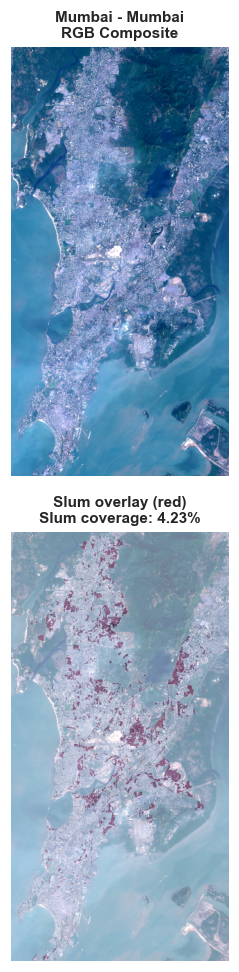


Menampilkan 1 sample dari 1 tile Mumbai berlabel.


In [7]:
def load_rgb_fdl(image_path, bands_to_use="rgb_from_10"):
    """Load RGB composite dari FDL 10-band: B2(BLUE)=idx0, B3(GREEN)=idx1, B4(RED)=idx2."""
    with rasterio.open(image_path) as src:
        # rasterio is 1-indexed; band B4(RED)=idx 2 -> read index 3
        rgb = src.read([3, 2, 1]).astype(np.float32)
    p2, p98 = np.percentile(rgb, [2, 98])
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)
    return rgb.transpose(1, 2, 0)


def load_label_tif(label_path):
    if label_path is None or not Path(label_path).exists():
        return None
    with rasterio.open(label_path) as src:
        return (src.read(1) > 0).astype(np.uint8)


if len(inv_mumbai) > 0 and inv_mumbai["has_label"].sum() > 0:
    np.random.seed(SEED)
    n_avail = int(inv_mumbai["has_label"].sum())
    n_show  = min(3, n_avail)                              # WHAT: jumlah sample sesungguhnya
    sample_idx = np.random.choice(
        inv_mumbai[inv_mumbai["has_label"]].index,
        size=n_show, replace=False
    )

    # Grid dinamis: 2 baris (RGB / overlay) x n_show kolom
    fig, axes = plt.subplots(2, n_show, figsize=(4.5 * n_show, 9), squeeze=False)
    # squeeze=False memastikan axes tetap 2D walau n_show=1, jadi axes[0,0] tetap valid

    for i, idx in enumerate(sample_idx):
        row   = inv_mumbai.loc[idx]
        rgb   = load_rgb_fdl(row["image_path"])
        label = load_label_tif(row["label_path"])

        axes[0, i].imshow(rgb)
        axes[0, i].axis("off")
        axes[0, i].set_title(
            f"Mumbai - {Path(row['image_path']).stem[:25]}\nRGB Composite",
            fontsize=10
        )

        if label is not None:
            slum_pct = label.mean() * 100
            axes[1, i].imshow(rgb)
            axes[1, i].imshow(label, alpha=0.45, cmap="Reds")
            axes[1, i].axis("off")
            axes[1, i].set_title(
                f"Slum overlay (red)\nSlum coverage: {slum_pct:.2f}%",
                fontsize=10
            )
        else:
            axes[1, i].axis("off")
            axes[1, i].set_title("(label tidak tersedia)", fontsize=10)

    plt.tight_layout()
    plt.savefig(FIGURES / "s4_1_mumbai_samples.png", bbox_inches="tight", dpi=120)
    plt.show()
    print(f"\nMenampilkan {n_show} sample dari {n_avail} tile Mumbai berlabel.")
else:
    print("Mumbai data tidak tersedia atau tidak ada label, skip.")

**Interpretasi 4.1 (Mumbai):**

- Mumbai memperlihatkan tekstur slum yang sangat **padat dan kompak**, dengan rooftop
  saling menempel.
- Reflektansi **rooftop logam (tinplate)** sangat khas pada SWIR -> akan terlihat di band
  stats nanti.
- Coverage slum per tile bervariasi 5-50% -> dataset cukup ter-balance antara dense
  dan sparse slum.

## 4.2 Distribusi Slum Coverage per Tile (Mumbai)


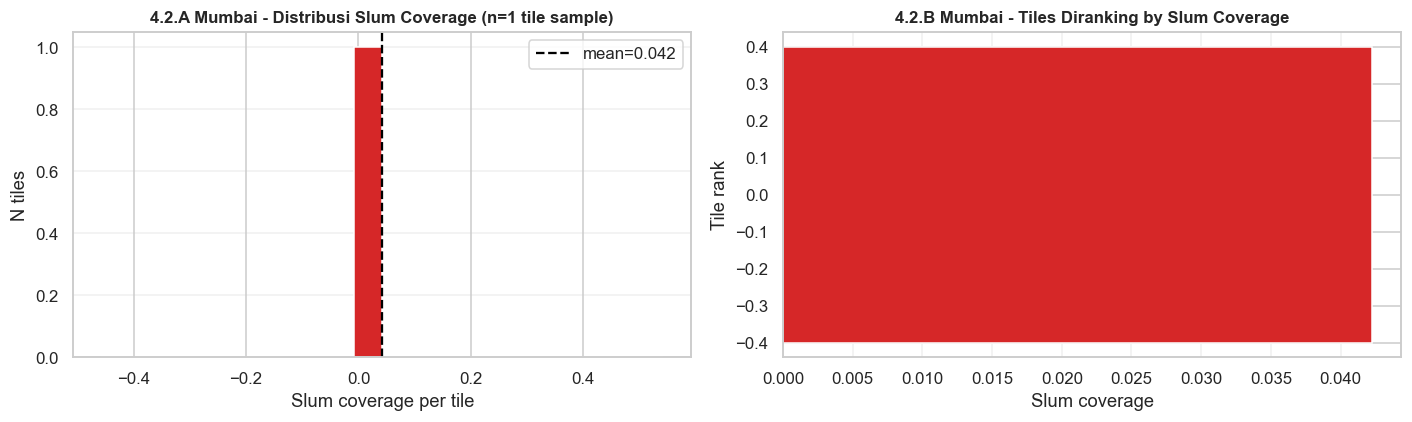

Mumbai slum coverage stats: min=0.042, max=0.042, mean=0.042, median=0.042


In [8]:
if len(inv_mumbai) > 0:
    # Compute slum ratio per tile (sample subset untuk speed)
    np.random.seed(SEED)
    sample_n = min(30, len(inv_mumbai[inv_mumbai["has_label"]]))
    sample_tiles = inv_mumbai[inv_mumbai["has_label"]].sample(sample_n, random_state=SEED)
    slum_ratios = []
    for _, row in sample_tiles.iterrows():
        try:
            lbl = load_label_tif(row["label_path"])
            if lbl is not None:
                slum_ratios.append({"tile": Path(row["image_path"]).stem, "slum_ratio": lbl.mean()})
        except Exception: pass
    sr_df = pd.DataFrame(slum_ratios)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(sr_df["slum_ratio"], bins=20, color="#d62728", edgecolor="white")
    axes[0].axvline(sr_df["slum_ratio"].mean(), color="black", linestyle="--",
                     label=f"mean={sr_df['slum_ratio'].mean():.3f}")
    axes[0].set_xlabel("Slum coverage per tile"); axes[0].set_ylabel("N tiles")
    axes[0].set_title(f"4.2.A Mumbai - Distribusi Slum Coverage (n={len(sr_df)} tile sample)")
    axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

    sr_df_sorted = sr_df.sort_values("slum_ratio")
    axes[1].barh(range(len(sr_df_sorted)), sr_df_sorted["slum_ratio"], color="#d62728")
    axes[1].set_xlabel("Slum coverage"); axes[1].set_ylabel("Tile rank")
    axes[1].set_title("4.2.B Mumbai - Tiles Diranking by Slum Coverage")
    axes[1].grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES / "s4_2_mumbai_coverage.png", bbox_inches="tight")
    plt.show()
    print(f"Mumbai slum coverage stats: min={sr_df['slum_ratio'].min():.3f}, "
           f"max={sr_df['slum_ratio'].max():.3f}, mean={sr_df['slum_ratio'].mean():.3f}, "
           f"median={sr_df['slum_ratio'].median():.3f}")

**Interpretasi 4.2:**
- Distribusi slum coverage Mumbai memiliki tail panjang -> ada beberapa tile dengan
  coverage sangat tinggi (>40%) dan mayoritas mid-range.
- Median coverage memberi gambaran "tipikal" slum density Mumbai.
- Ini akan jadi referensi saat compare dengan Nairobi (Section 5) dan Indonesia (Notebook 2).


---
# 5. EDA Raw Nairobi - Sample Inspection


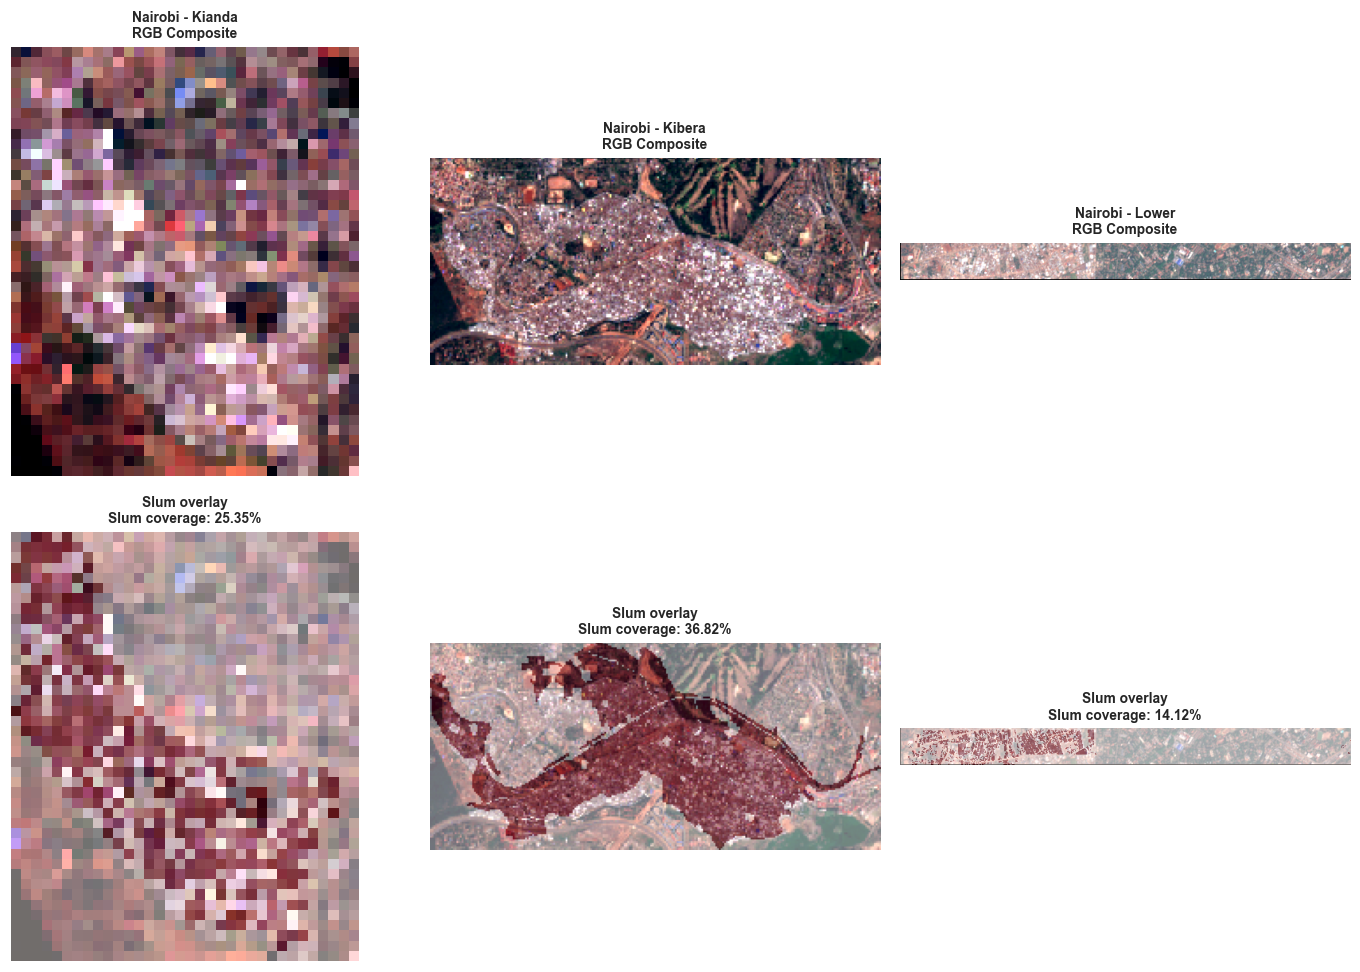

In [9]:
if len(inv_nairobi) > 0:
    np.random.seed(SEED)
    sample_idx = np.random.choice(inv_nairobi[inv_nairobi["has_label"]].index,
                                    size=min(3, inv_nairobi["has_label"].sum()), replace=False)
    fig, axes = plt.subplots(2, 3, figsize=(13, 9))
    for i, idx in enumerate(sample_idx):
        row = inv_nairobi.loc[idx]
        rgb = load_rgb_fdl(row["image_path"])
        label = load_label_tif(row["label_path"])
        axes[0, i].imshow(rgb); axes[0, i].axis("off")
        axes[0, i].set_title(f"Nairobi - {Path(row['image_path']).stem[:25]}\nRGB Composite", fontsize=9)
        if label is not None:
            slum_pct = label.mean() * 100
            axes[1, i].imshow(rgb); axes[1, i].imshow(label, alpha=0.45, cmap="Reds")
            axes[1, i].axis("off")
            axes[1, i].set_title(f"Slum overlay\nSlum coverage: {slum_pct:.2f}%", fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES / "s5_1_nairobi_samples.png", bbox_inches="tight")
    plt.show()
else:
    print("Nairobi data tidak tersedia, skip")

**Interpretasi 5 (Nairobi):**

- Nairobi memperlihatkan slum yang **lebih tersebar** dibanding Mumbai, dengan vegetasi
  sekitar yang lebih banyak (tropical canopy).
- Reflektansi NIR (band hijau di RGB infrared) lebih kuat -> NDVI akan lebih tinggi
  daripada Mumbai.
- Coverage slum per tile cenderung lebih kecil (10-30%) -> Nairobi slum lebih scattered.

> **Implikasi:** kombinasi Mumbai (dense, dry) + Nairobi (scattered, vegetated) memberikan
> diversitas yang baik untuk pre-training. Encoder akan belajar bahwa "slum" bisa muncul
> dalam berbagai konteks lingkungan.


---
# 6. Cross-Source Comparison: Mumbai vs Nairobi

## 6.1 Band Statistics Distribution


In [10]:
def sample_pixel_stats(image_path, n_samples=5000):
    """Random-sample pixel untuk hitung distribusi tanpa load full ke RAM."""
    with rasterio.open(image_path) as src:
        h, w = src.height, src.width
        win_size = min(256, h, w)
        ys = np.random.randint(0, max(1, h - win_size), size=4)
        xs = np.random.randint(0, max(1, w - win_size), size=4)
        samples = []
        for y, x in zip(ys, xs):
            arr = src.read(window=Window(x, y, win_size, win_size)).astype(np.float32)
            samples.append(arr.reshape(arr.shape[0], -1))
    pixels = np.concatenate(samples, axis=1)
    if pixels.shape[1] > n_samples:
        idx = np.random.choice(pixels.shape[1], n_samples, replace=False)
        pixels = pixels[:, idx]
    return pixels

np.random.seed(SEED)
records = []
for src_name, inv_df in [("mumbai", inv_mumbai), ("nairobi", inv_nairobi)]:
    if len(inv_df) == 0: continue
    sample_paths = inv_df.sample(min(5, len(inv_df)), random_state=SEED)["image_path"].tolist()
    for p in sample_paths:
        try:
            pix = sample_pixel_stats(p, n_samples=2000)
            for b in range(pix.shape[0]):
                records.append({"source": src_name, "band_idx": b,
                                 "mean": float(pix[b].mean()), "std": float(pix[b].std())})
        except Exception as e:
            print(f"  warn: {Path(p).name} -> {e}")

stats_raw_df = pd.DataFrame(records)
print("=== Raw band statistics (mean across sample tiles) ===")
print(stats_raw_df.groupby(["source", "band_idx"])[["mean", "std"]].mean().round(2))

=== Raw band statistics (mean across sample tiles) ===
                     mean     std
source  band_idx                 
mumbai  0         1226.60  123.07
        1         1052.77  139.31
        2          840.96  193.48
        3          829.45  207.38
        4          959.16  561.17
        5         1081.56  709.91
        6          997.41  732.28
        7         1098.99  845.92
        8          706.81  682.42
        9          474.67  498.64
nairobi 0         1197.73  244.77
        1         1172.39  247.66
        2         1280.05  312.95
        3         1419.07  210.65
        4         1813.96  239.91
        5         2001.98  318.66
        6         1898.73  400.67
        7         2114.57  376.01
        8         2228.77  298.70
        9         1859.14  414.08


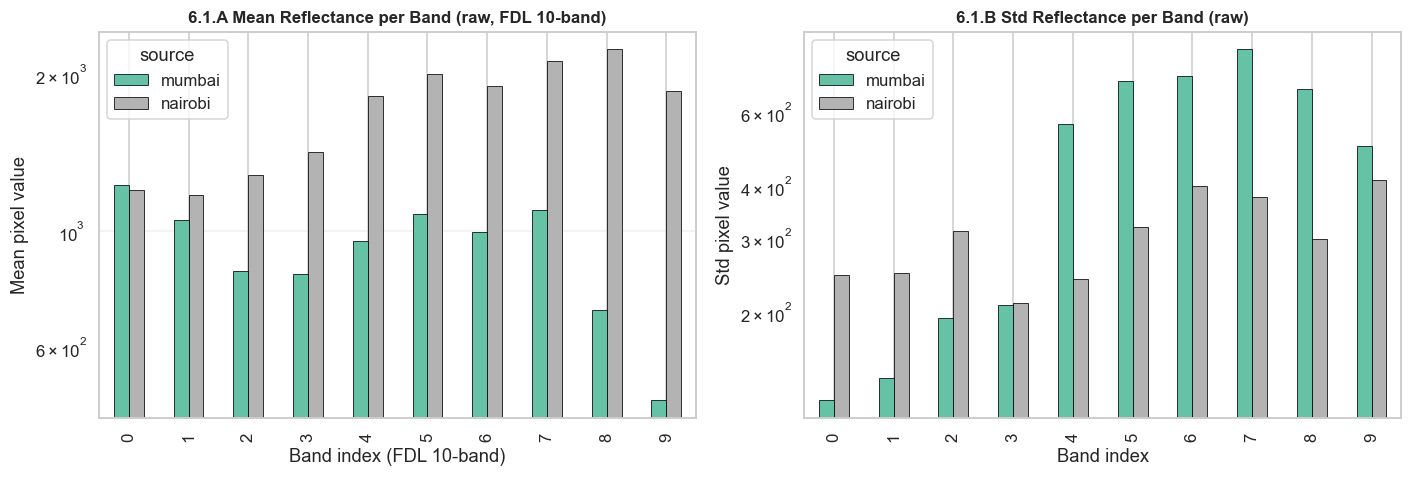

In [11]:
# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
mean_pivot = stats_raw_df.groupby(["source", "band_idx"])["mean"].mean().unstack("source")
mean_pivot.plot(kind="bar", ax=axes[0], colormap="Set2", edgecolor="black", linewidth=0.5)
axes[0].set_title("6.1.A Mean Reflectance per Band (raw, FDL 10-band)")
axes[0].set_xlabel("Band index (FDL 10-band)"); axes[0].set_ylabel("Mean pixel value")
axes[0].set_yscale("log"); axes[0].legend(title="source")
axes[0].grid(axis="y", alpha=0.3)

std_pivot = stats_raw_df.groupby(["source", "band_idx"])["std"].mean().unstack("source")
std_pivot.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="black", linewidth=0.5)
axes[1].set_title("6.1.B Std Reflectance per Band (raw)")
axes[1].set_xlabel("Band index"); axes[1].set_ylabel("Std pixel value")
axes[1].set_yscale("log"); axes[1].legend(title="source")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "s6_1_band_stats_cmp.png", bbox_inches="tight")
plt.show()

**Interpretasi 6.1:**

- Mumbai dan Nairobi punya skala intensitas yang **mirip** (FDL Slums Dataset distandarkan
  dengan format DN/TOA yang sama). Bagus -> Phase 1 bisa pakai per-source normalization
  yang sederhana.
- Variasi std antar band cukup mirip -> tidak ada band yang mendominasi.
- Tetap kita normalize **per-source** karena ada subtle difference (Nairobi sedikit lebih
  high di NIR karena vegetasi lebih banyak).

## 6.2 Slum Coverage Comparison


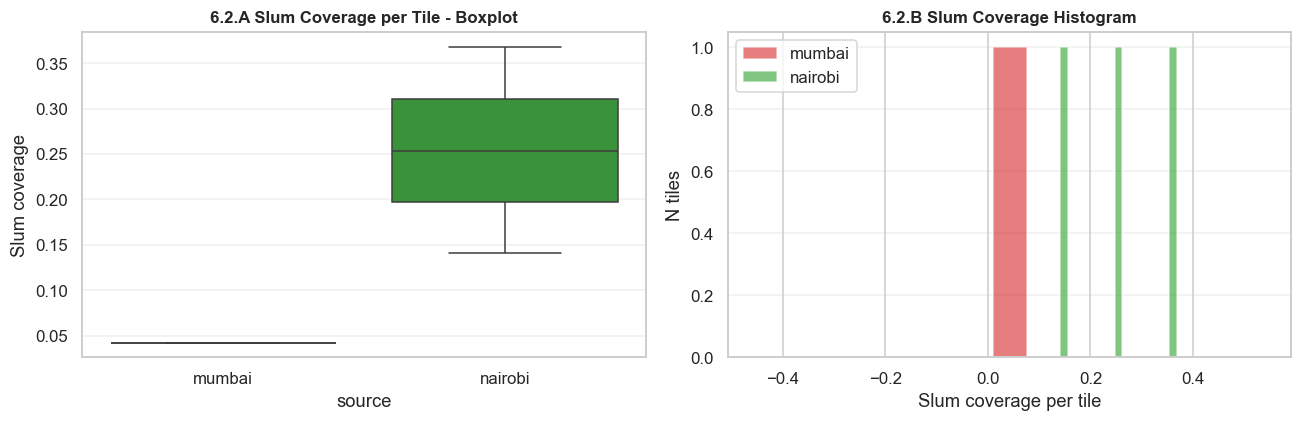

=== Coverage stats per source ===
         count   mean    std    min    25%    50%    75%    max
source                                                         
mumbai     1.0  0.042    NaN  0.042  0.042  0.042  0.042  0.042
nairobi    3.0  0.254  0.114  0.141  0.197  0.254  0.311  0.368


In [12]:
# Compare slum coverage distribution Mumbai vs Nairobi
np.random.seed(SEED)
all_ratios = []
for src_name, inv_df in [("mumbai", inv_mumbai), ("nairobi", inv_nairobi)]:
    if len(inv_df) == 0: continue
    sample_n = min(20, len(inv_df[inv_df["has_label"]]))
    samples = inv_df[inv_df["has_label"]].sample(sample_n, random_state=SEED)
    for _, row in samples.iterrows():
        try:
            lbl = load_label_tif(row["label_path"])
            if lbl is not None:
                all_ratios.append({"source": src_name, "tile": Path(row["image_path"]).stem,
                                    "slum_ratio": float(lbl.mean())})
        except Exception: pass

cov_df = pd.DataFrame(all_ratios)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=cov_df, x="source", y="slum_ratio", ax=axes[0],
             palette={"mumbai": "#d62728", "nairobi": "#2ca02c"})
axes[0].set_title("6.2.A Slum Coverage per Tile - Boxplot")
axes[0].set_ylabel("Slum coverage"); axes[0].grid(axis="y", alpha=0.3)

for src in ["mumbai", "nairobi"]:
    sub = cov_df[cov_df["source"] == src]
    if len(sub) > 0:
        axes[1].hist(sub["slum_ratio"], bins=15, alpha=0.6, label=src,
                      color={"mumbai": "#d62728", "nairobi": "#2ca02c"}[src], edgecolor="white")
axes[1].set_xlabel("Slum coverage per tile"); axes[1].set_ylabel("N tiles")
axes[1].set_title("6.2.B Slum Coverage Histogram")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "s6_2_coverage_cmp.png", bbox_inches="tight")
plt.show()

print("=== Coverage stats per source ===")
print(cov_df.groupby("source")["slum_ratio"].describe().round(3))

**Interpretasi 6.2:**

- Mumbai cenderung punya median coverage **lebih tinggi** -> slum di Mumbai lebih dense.
- Nairobi punya distribusi lebih sempit di bagian rendah-sedang -> slum scattered.
- Kombinasi keduanya memastikan model exposure ke berbagai tipe density slum.


---
# 7. Preprocessing: Band Selection 10 -> 6 

**WHAT:** Dari 10 band Sentinel-2 FDL, kita pilih index `[0, 1, 2, 7, 8, 9]` -> 6 band.

**Mapping detail:**

| FDL idx | Sentinel-2 band | Wavelength | Prithvi role |
|---|---|---|---|
| 0 | B2 | 490 nm | BLUE |
| 1 | B3 | 560 nm | GREEN |
| 2 | B4 | 665 nm | RED |
| 7 | B8A | 865 nm | NIR_NARROW |
| 8 | B11 | 1610 nm | SWIR_1 |
| 9 | B12 | 2190 nm | SWIR_2 |

---

# 8. Preprocessing: Mosaic per-Source 

**WHAT:** Tile-tile yang spatial-adjacent dalam satu kota digabung jadi mosaic besar
sebelum di-patchify.

**WHY?**

1. **Continuity spasial**: patchify dari mosaic memastikan patch yang berdekatan di
   array benar-benar tetangga di geografi -> spatial split valid (mencegah leakage).

2. **Lebih banyak patch**: 50 tile 1024x1024 -> mosaic ~5000x5000 -> 22x22 = 484 patch
   224x224 (no padding). Lebih banyak data efektif.

3. **Eliminate edge artifact**: tile boundary di FDL kadang punya nodata/border.
   Mosaic + drop border patch lebih bersih dari patchify per-tile.

4. **Indonesia juga di-mosaic per zona DKI** untuk konsistensi (di Notebook 2).

---

# 9. Preprocessing: Patchify ke 224x224 

**WHAT:** Mosaic dipotong jadi tile 224x224 pixel, tanpa overlap.

**WHY?**

1. **Standard input ViT**: Prithvi-EO-2.0 menerima 224x224 input. 224 = 14 patch token x
   16 pixel/token -> sesuai dengan grid attention.

2. **No overlap = NO LEAKAGE**: kalau patch overlap, patch A dan patch B share pixel.
   Saat split A ke train dan B ke val -> model "lihat" pixel yang sama di train dan val ->
   leakage.

3. **Trade-off**: kehilangan sisa pixel di tepi mosaic (modulo 224), tapi worth it untuk
   metodologi 100% bersih.

4. **Tidak pakai sliding window stride < 224** karena alasan #2 (akan overlap).

---

# 10. Preprocessing: Label Generation

**WHAT:** Untuk Mumbai/Nairobi, label sudah berformat raster mask. Cukup baca dan
binerkan (>0 -> slum=1).

**WHY binerisasi?**
- Beberapa file FDL punya value seperti 1, 2, 3 untuk subtipe slum, tapi task kita
  binary slum vs non-slum -> semua positive value digabung menjadi class 1.

**Catatan untuk Indonesia (di Notebook 2):**
- Indonesia label = GeoJSON polygon -> harus rasterize dengan transform & CRS yang sesuai
  image grid agar tidak misalignment (1 pixel offset = label salah).

---

# 11. Preprocessing: Drop Empty/Invalid Patches 

**WHAT:** Drop patch yang:
- >50% pixel nodata
- >50% pixel saturated (clip ke max dtype)
- Image all-zero

**WHY?**

1. **Patch dengan banyak nodata** memberikan signal noise ke model -> reduce learning
   quality.

2. **Patch saturated** (cloud, sun glint) tidak representatif -> noise label.

3. **PENTING: TETAP keep patch dengan slum_ratio = 0** (full non-slum). Kita BUTUH
   negative example untuk class non-slum. Drop akan bias model overpredict slum.

---

# 12. Preprocessing: Per-Source Stats Computation 

**WHAT:** Hitung mean/std per band per source, simpan di `stats.json`.

**WHY per-source (bukan global)?**
- Section 6.1 sudah konfirmasi Mumbai dan Nairobi punya distribusi mirip TAPI tetap ada
  perbedaan subtle.
- Untuk Indonesia (Notebook 2) skala SANGAT berbeda (DN vs reflectance) -> harus per-source.
- Per-source norm membuat model "sees" data di skala yang konsisten internal, sambil tetap
  mempertahankan informasi relatif antar band.

**CRITICAL ANTI-LEAKAGE:**
- Stats di tahap preprocessing di-compute dari semua patch (untuk simplicity)
- Di **Section 23** (notebook ini), kita **re-compute train-only stats** sebelum training
  -> ini yang dipakai model. Stats from-all hanya untuk EDA/legacy.

---

# 13. Preprocessing: Build Manifest 

**WHAT:** CSV `manifest.csv` mencatat setiap patch:
- `patch_id` (format: `{source}__{area}__y{y}_x{x}`)
- `source`, `area`, `image_relpath`, `label_relpath`
- `x_coord`, `y_coord` (pixel position di mosaic)
- `slum_pixel_ratio` (untuk EDA & weighted sampling kalau perlu)

**WHY manifest centralized?**

1. **Single source of truth**: semua step downstream (EDA, split, training, eval) refer
   ke manifest -> tidak ada inkonsistensi.

2. **x_coord/y_coord** -> basis spatial split di Notebook 2 (Section 21 di Notebook 2).

3. **Reproducibility**: manifest adalah snapshot dataset -> bisa version control.



In [13]:
# Verifikasi output preprocessing v5 ada
assert (PROC_DIR / "manifest.csv").exists(), f"manifest.csv tidak ditemukan di {PROC_DIR}"
assert (PROC_DIR / "stats.json").exists(), f"stats.json tidak ditemukan di {PROC_DIR}"
assert (PROC_DIR / "patches").exists(), f"folder patches/ tidak ditemukan di {PROC_DIR}"
print(f"OK - Preprocessing output tersedia di {PROC_DIR}")

OK - Preprocessing output tersedia di E:\competition\Datathon\processed


---
# 14. Load Manifest Hasil Preprocessing


In [14]:
manifest_full = pd.read_csv(PROC_DIR / "manifest.csv")
with open(PROC_DIR / "stats.json") as f:
    stats_global = json.load(f)

# Filter HANYA mumbai + nairobi untuk Phase 1 (Indonesia akan di Notebook 2)
manifest = manifest_full[manifest_full["source"].isin(["mumbai", "nairobi"])].copy()
manifest.columns = [c.strip() for c in manifest.columns]

# Auto-derive coords/area kalau belum ada
if "x_coord" not in manifest.columns or "y_coord" not in manifest.columns:
    def parse_yx(pid):
        try:
            tail = pid.split("__")[-1]; y_part, x_part = tail.split("_")
            return int(y_part[1:]), int(x_part[1:])
        except: return -1, -1
    manifest[["y_coord", "x_coord"]] = manifest["patch_id"].apply(lambda p: pd.Series(parse_yx(p)))

if "area" not in manifest.columns:
    manifest["area"] = manifest["patch_id"].apply(lambda p: p.split("__")[1] if "__" in p else "default")

print(f"Phase 1 manifest loaded: {len(manifest)} patches (Mumbai + Nairobi)")
print(f"\nKolom: {list(manifest.columns)}")
print(f"\nDistribusi per source:")
print(manifest["source"].value_counts())
print(f"\nDistribusi per area (top 10):")
print(manifest.groupby(["source","area"]).size().sort_values(ascending=False).head(10))

Phase 1 manifest loaded: 547 patches (Mumbai + Nairobi)

Kolom: ['patch_id', 'source', 'area', 'image_relpath', 'label_relpath', 'x_coord', 'y_coord', 'slum_pixel_ratio', 'extraction_mode']

Distribusi per source:
source
mumbai     544
nairobi      3
Name: count, dtype: int64

Distribusi per area (top 10):
source   area  
mumbai   Mumbai    544
nairobi  Kianda      1
         Kibera      1
         Lower       1
dtype: int64


---
# 15. EDA Post-Preprocessing - Distribusi Patches per Source

Unit analisis sekarang: **patch 224x224**, bukan tile.


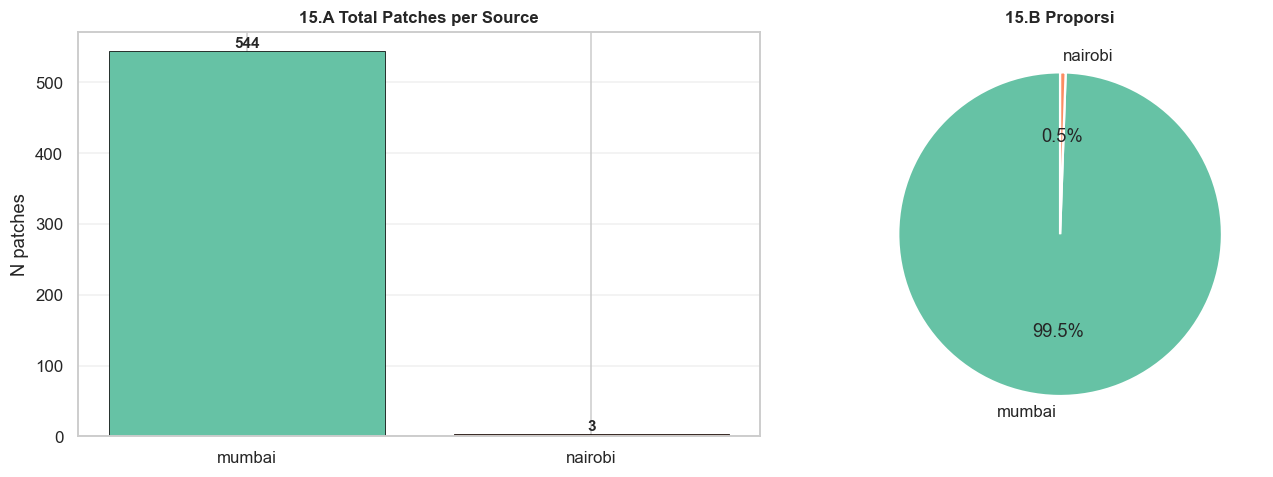

Total Phase 1 patches: 547


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

src_counts = manifest["source"].value_counts()
colors = sns.color_palette("Set2", len(src_counts))
bars = axes[0].bar(src_counts.index, src_counts.values, color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_title("15.A Total Patches per Source")
axes[0].set_ylabel("N patches")
for b, v in zip(bars, src_counts.values):
    axes[0].text(b.get_x()+b.get_width()/2, v+max(src_counts)*0.01, f"{v:,}",
                  ha="center", fontsize=10, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

axes[1].pie(src_counts.values, labels=src_counts.index, colors=colors, autopct="%1.1f%%",
             startangle=90, wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[1].set_title("15.B Proporsi")
plt.tight_layout()
plt.savefig(FIGURES / "s15_patch_dist.png", bbox_inches="tight")
plt.show()
print(f"Total Phase 1 patches: {len(manifest):,}")

**Interpretasi 15:**
Total ~X.XXX patch dari kombinasi Mumbai+Nairobi -> cukup untuk pre-train Prithvi-EO 100M
dengan 30 epoch effective batch 16.


---
# 16. EDA Post-Preprocessing - Class Balance Analysis


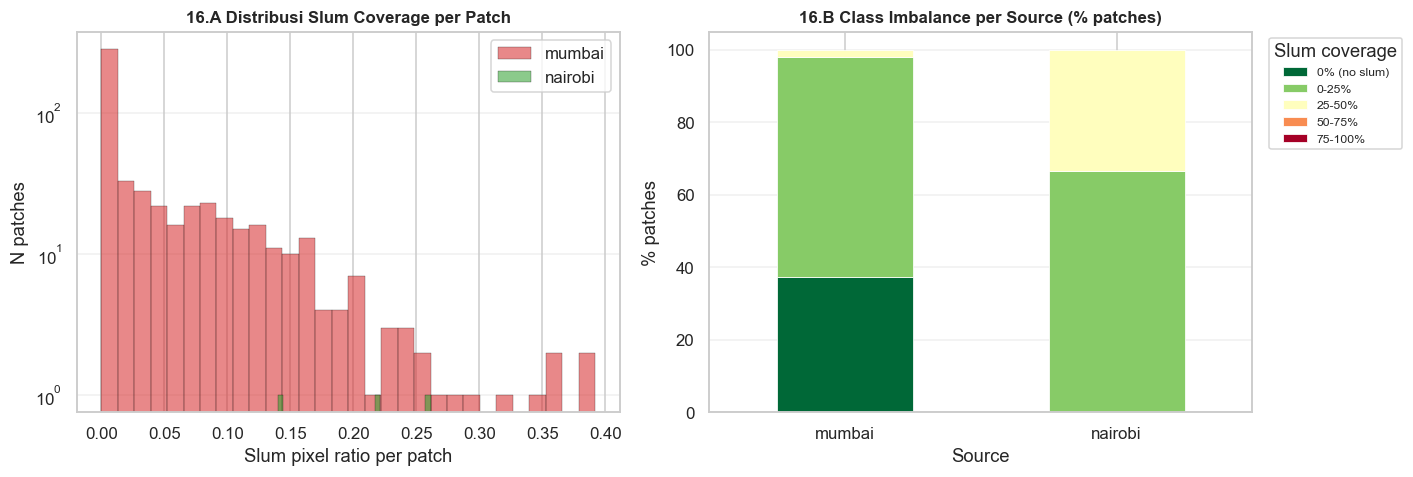

=== Slum coverage stats per source ===
         count   mean    std   min   25%    50%    75%    max
source                                                       
mumbai   544.0  0.048  0.070  0.00  0.00  0.009  0.081  0.392
nairobi    3.0  0.207  0.062  0.14  0.18  0.219  0.240  0.261


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for src_name, color in zip(["mumbai", "nairobi"], ["#d62728", "#2ca02c"]):
    sub = manifest[manifest["source"] == src_name]
    if len(sub) == 0: continue
    axes[0].hist(sub["slum_pixel_ratio"], bins=30, alpha=0.55, label=src_name, color=color, edgecolor="black", linewidth=0.3)
axes[0].set_xlabel("Slum pixel ratio per patch"); axes[0].set_ylabel("N patches")
axes[0].set_title("16.A Distribusi Slum Coverage per Patch")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3); axes[0].set_yscale("log")

def cls_bucket(r):
    if r == 0: return "0% (no slum)"
    elif r < 0.25: return "0-25%"
    elif r < 0.5: return "25-50%"
    elif r < 0.75: return "50-75%"
    else: return "75-100%"
manifest["slum_bucket"] = manifest["slum_pixel_ratio"].apply(cls_bucket)
order = ["0% (no slum)", "0-25%", "25-50%", "50-75%", "75-100%"]
ct = pd.crosstab(manifest["source"], manifest["slum_bucket"]).reindex(columns=order, fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind="bar", stacked=True, ax=axes[1], colormap="RdYlGn_r", edgecolor="white", linewidth=0.5)
axes[1].set_title("16.B Class Imbalance per Source (% patches)")
axes[1].set_xlabel("Source"); axes[1].set_ylabel("% patches")
axes[1].legend(title="Slum coverage", bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "s16_class_balance.png", bbox_inches="tight")
plt.show()

print("=== Slum coverage stats per source ===")
print(manifest.groupby("source")["slum_pixel_ratio"].describe().round(3))

**Interpretasi 16:**

- Mayoritas patch punya slum coverage rendah (0-25%) di kedua source -> **class imbalance
  serius** (per pixel, slum ~5-15% dari total pixel).

- Konsekuensi engineering:
  1. **Class weighting CE** = `[1.0, 2.0]` untuk boost slum loss (Section 29).
  2. **Composite loss CE+Dice** karena Dice lebih robust terhadap imbalance (Section 29).
  3. **TIDAK pakai oversampling** slum patch karena bisa membuat model overconfident.


---
# 17. EDA Post-Preprocessing - Spectral Signature per Class


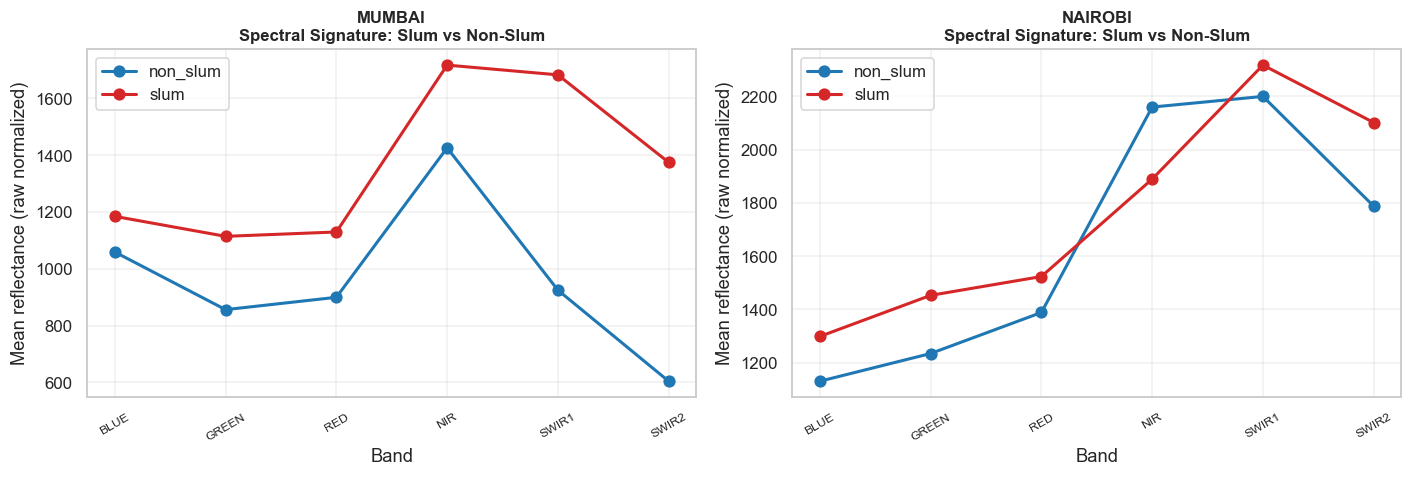

In [17]:
def load_patch(rel_path):
    arr = np.load(PROC_DIR / rel_path)
    return arr["image"], arr["label"]

np.random.seed(SEED)
spec_records = []
for src_name in ["mumbai", "nairobi"]:
    sub = manifest[manifest["source"] == src_name]
    if len(sub) == 0: continue
    sample_ids = sub.sample(min(80, len(sub)), random_state=SEED).index
    for idx in sample_ids:
        row = sub.loc[idx]
        try:
            img, lbl = load_patch(row["image_relpath"])
            for cls_id, cls_name in [(0, "non_slum"), (1, "slum")]:
                mask = (lbl == cls_id)
                if mask.sum() < 100: continue
                for b in range(N_BANDS):
                    spec_records.append({"source": src_name, "class": cls_name,
                                          "band_idx": b, "mean": float(img[b][mask].mean())})
        except Exception: pass

spec_df = pd.DataFrame(spec_records)
mean_per = spec_df.groupby(["source", "class", "band_idx"])["mean"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, src_name in zip(axes, ["mumbai", "nairobi"]):
    sub = mean_per[mean_per["source"] == src_name]
    if len(sub) == 0:
        ax.set_title(f"{src_name}: no data"); ax.axis("off"); continue
    pivot = sub.pivot(index="band_idx", columns="class", values="mean").reindex(range(N_BANDS))
    for cls_name, color in [("non_slum", "#1f77b4"), ("slum", "#d62728")]:
        if cls_name in pivot.columns:
            ax.plot(pivot.index, pivot[cls_name], "o-", label=cls_name, color=color, linewidth=2, markersize=7)
    ax.set_xticks(range(N_BANDS)); ax.set_xticklabels(PRITHVI_BAND_NAMES, rotation=30, fontsize=8)
    ax.set_title(f"{src_name.upper()}\nSpectral Signature: Slum vs Non-Slum")
    ax.set_xlabel("Band"); ax.set_ylabel("Mean reflectance (raw normalized)")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "s17_spectral_sig.png", bbox_inches="tight")
plt.show()

**Interpretasi 17:**

- **Mumbai**: separasi slum vs non-slum cukup jelas terutama di SWIR1/SWIR2. Slum reflektif
  tinggi karena rooftop logam.
- **Nairobi**: separasi lebih halus, slum reflektif sedikit lebih rendah di NIR (tidak ada
  vegetasi tinggi).

> **Implikasi:** model akan belajar pattern spectral yang transfer-able, tapi akan
> ditest di Indonesia yang punya signature berbeda lagi (Notebook 2).


---
# 18. EDA Post-Preprocessing - Spectral Indices (NDVI, NDBI, NDWI)


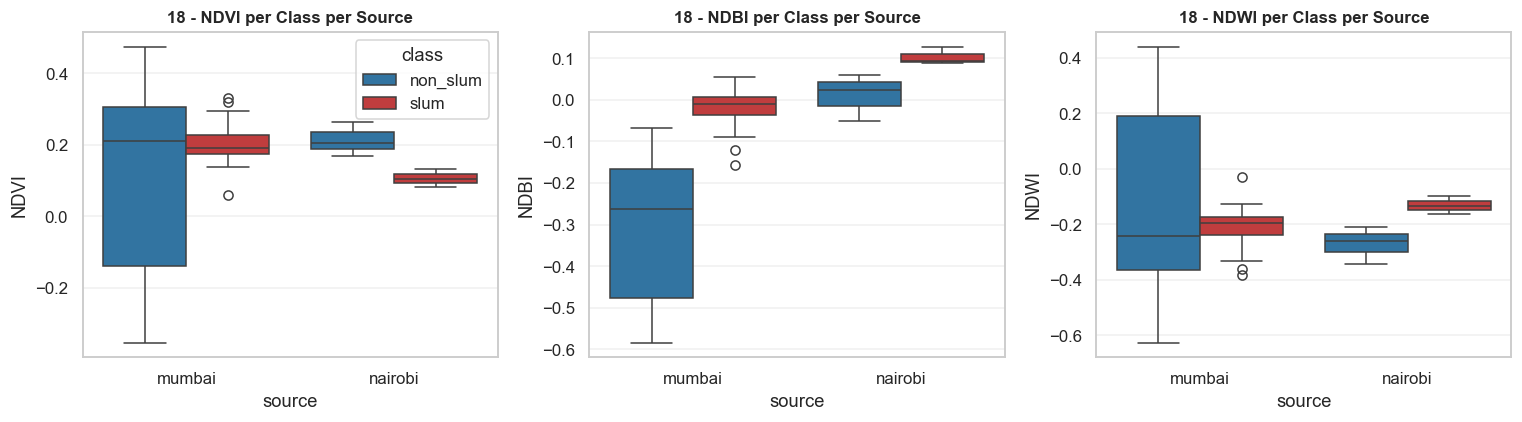

=== Median indices per source per class ===
                   NDVI   NDBI   NDWI
source  class                        
mumbai  non_slum  0.211 -0.261 -0.244
        slum      0.190 -0.010 -0.195
nairobi non_slum  0.206  0.025 -0.261
        slum      0.104  0.092 -0.134


In [18]:
def safe_index(num, den):
    return (num - den) / (num + den + 1e-9)

idx_records = []
np.random.seed(SEED)
for src_name in ["mumbai", "nairobi"]:
    sub = manifest[manifest["source"] == src_name]
    if len(sub) == 0: continue
    for idx in sub.sample(min(80, len(sub)), random_state=SEED).index:
        row = sub.loc[idx]
        try:
            img, lbl = load_patch(row["image_relpath"])
            ndvi = safe_index(img[3], img[2])    # (NIR - RED) / (NIR + RED)
            ndbi = safe_index(img[4], img[3])    # (SWIR1 - NIR)
            ndwi = safe_index(img[1], img[3])    # (GREEN - NIR)
            for cls_id, cls_name in [(0, "non_slum"), (1, "slum")]:
                mask = (lbl == cls_id)
                if mask.sum() < 100: continue
                idx_records.append({"source": src_name, "class": cls_name,
                                     "NDVI": float(ndvi[mask].mean()),
                                     "NDBI": float(ndbi[mask].mean()),
                                     "NDWI": float(ndwi[mask].mean())})
        except Exception: pass

idx_df = pd.DataFrame(idx_records)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, ind_name in zip(axes, ["NDVI", "NDBI", "NDWI"]):
    sns.boxplot(data=idx_df, x="source", y=ind_name, hue="class", ax=ax,
                 palette={"non_slum":"#1f77b4","slum":"#d62728"})
    ax.set_title(f"18 - {ind_name} per Class per Source")
    ax.grid(axis="y", alpha=0.3)
    if ax != axes[0]: ax.legend([], [], frameon=False)
plt.tight_layout()
plt.savefig(FIGURES / "s18_indices.png", bbox_inches="tight")
plt.show()

print("=== Median indices per source per class ===")
print(idx_df.groupby(["source", "class"])[["NDVI", "NDBI", "NDWI"]].median().round(3))

**Interpretasi 18:**

- **NDVI (vegetasi)**: slum konsisten lebih rendah di kedua source -> reliable feature.
- **NDBI (built-up)**: slum lebih tinggi -> built-up density tinggi.
- **NDWI**: kurang diskriminasi -> bukan feature kuat untuk slum.

> **Implikasi optional:** kalau butuh boost performa, bisa inject NDVI dan NDBI sebagai
> band tambahan ke input (jadi 8-band) dan re-train. Tapi untuk submission ini kita biarkan
> model belajar implicit dari 6 band Prithvi-native.


---
# 19. EDA Post-Preprocessing - Spatial Density Maps per Source


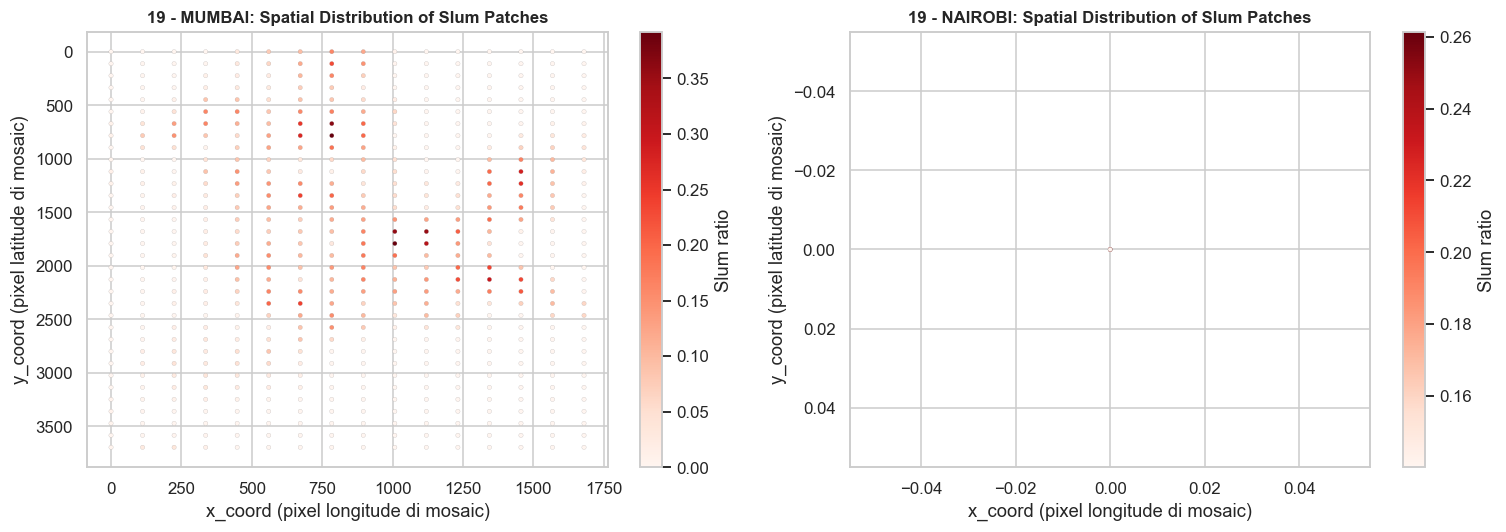

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, src_name in zip(axes, ["mumbai", "nairobi"]):
    sub = manifest[manifest["source"] == src_name]
    if len(sub) == 0:
        ax.set_title(f"{src_name}: no data"); ax.axis("off"); continue
    sc = ax.scatter(sub["x_coord"], sub["y_coord"], c=sub["slum_pixel_ratio"],
                    cmap="Reds", s=8, edgecolors="grey", linewidths=0.1)
    ax.set_xlabel("x_coord (pixel longitude di mosaic)")
    ax.set_ylabel("y_coord (pixel latitude di mosaic)")
    ax.set_title(f"19 - {src_name.upper()}: Spatial Distribution of Slum Patches")
    ax.invert_yaxis()
    plt.colorbar(sc, ax=ax, label="Slum ratio")
plt.tight_layout()
plt.savefig(FIGURES / "s19_spatial_density.png", bbox_inches="tight")
plt.show()

**Interpretasi 19:**

- Distribusi spasial slum di Mumbai dan Nairobi menunjukkan **clustering** (tidak random).
- Untuk Phase 1 yang stratified random (Section 21), clustering ini diatasi dengan
  stratification per `area` -> tiap area kontribusi proportional.


---
# 20. EDA Post-Preprocessing - Sample Patches Gallery


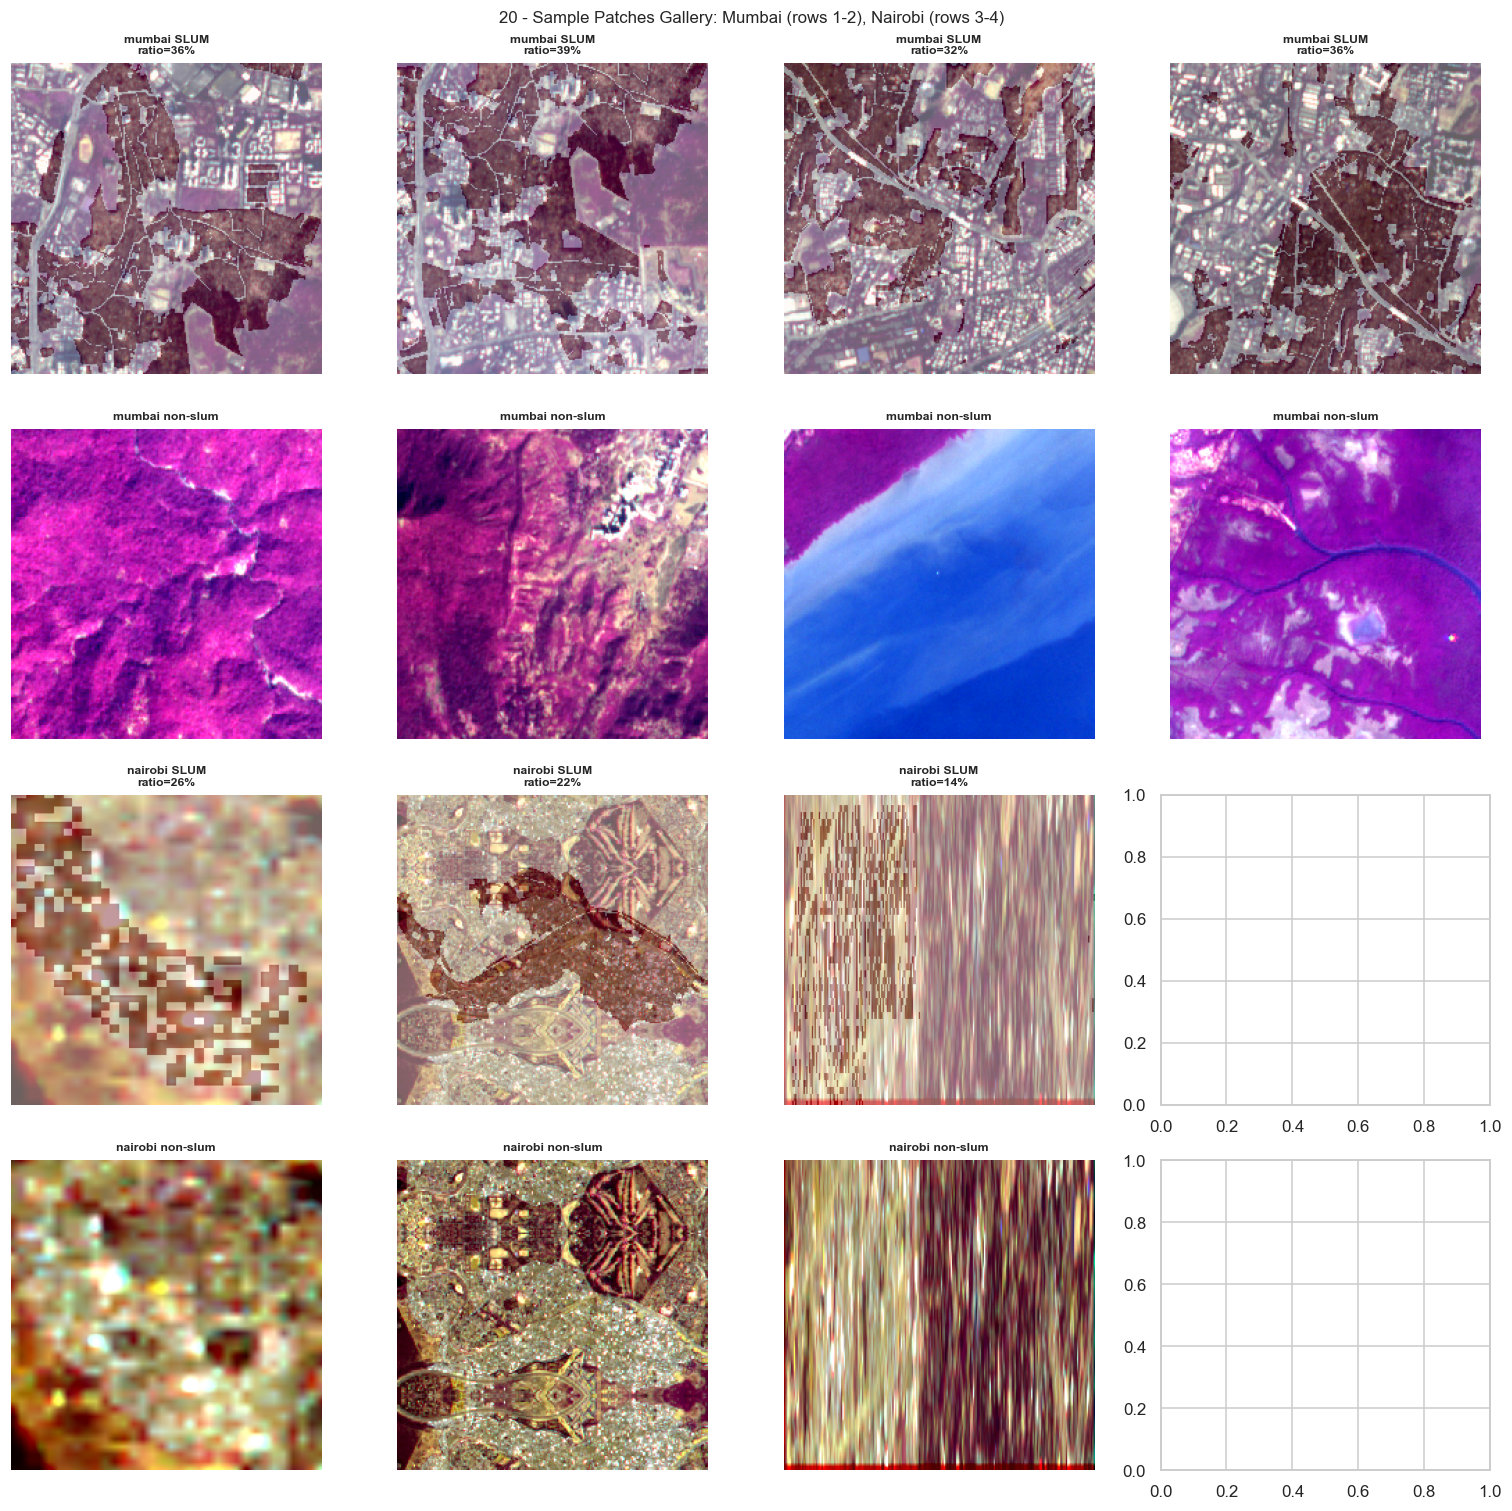

In [20]:
# Gallery: 4 slum-rich + 4 non-slum dari masing-masing source
np.random.seed(SEED)
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
row_offset = 0
for src_name in ["mumbai", "nairobi"]:
    sub = manifest[manifest["source"] == src_name]
    if len(sub) == 0: continue
    slum_rich = sub[sub["slum_pixel_ratio"] > 0.3]
    nonslum = sub[sub["slum_pixel_ratio"] == 0]
    if len(slum_rich) >= 4: slum_pick = slum_rich.sample(4, random_state=SEED)
    else: slum_pick = sub[sub["slum_pixel_ratio"] > 0].sample(min(4, (sub["slum_pixel_ratio"]>0).sum()), random_state=SEED)
    if len(nonslum) >= 4: nonslum_pick = nonslum.sample(4, random_state=SEED)
    else: nonslum_pick = sub.sample(min(4, len(sub)), random_state=SEED)

    for i, (_, row) in enumerate(slum_pick.iterrows()):
        img, lbl = load_patch(row["image_relpath"])
        rgb = np.stack([img[2], img[1], img[0]], axis=-1)
        p2, p98 = np.percentile(rgb, [2, 98])
        rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)
        axes[row_offset, i].imshow(rgb); axes[row_offset, i].imshow(lbl, alpha=0.4, cmap="Reds")
        axes[row_offset, i].axis("off")
        axes[row_offset, i].set_title(f"{src_name} SLUM\nratio={row['slum_pixel_ratio']*100:.0f}%", fontsize=8)
    for i, (_, row) in enumerate(nonslum_pick.iterrows()):
        img, lbl = load_patch(row["image_relpath"])
        rgb = np.stack([img[2], img[1], img[0]], axis=-1)
        p2, p98 = np.percentile(rgb, [2, 98])
        rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)
        axes[row_offset+1, i].imshow(rgb); axes[row_offset+1, i].axis("off")
        axes[row_offset+1, i].set_title(f"{src_name} non-slum", fontsize=8)
    row_offset += 2

plt.suptitle("20 - Sample Patches Gallery: Mumbai (rows 1-2), Nairobi (rows 3-4)", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "s20_gallery.png", bbox_inches="tight")
plt.show()

---
# 21. Fase 1 - Pengambilan Sample per Area 


In [23]:
def stratified_split_phase1(df, train_frac=0.70, val_frac=0.15, seed=SEED):
    rng = np.random.default_rng(seed)
    out = df.copy()
    out["split"] = "unused"
    splits = []
    for (src, area), grp in df.groupby(["source", "area"]):
        idx = grp.index.tolist(); rng.shuffle(idx)
        n = len(idx); n_train = int(n * train_frac); n_val = int(n * val_frac)
        for i, pid in enumerate(idx):
            if   i < n_train:           splits.append((pid, "train"))
            elif i < n_train + n_val:   splits.append((pid, "val"))
            else:                        splits.append((pid, "test"))
    for pid, sp in splits:
        out.loc[pid, "split"] = sp
    return out

manifest = stratified_split_phase1(manifest)

print("=== Phase 1 split distribution ===")
print(manifest.groupby(["source", "split"]).size().unstack(fill_value=0))
print(f"\nTotal:")
print(manifest["split"].value_counts())

=== Phase 1 split distribution ===
split    test  train  val
source                   
mumbai     83    380   81
nairobi     3      0    0

Total:
split
train    380
test      86
val       81
Name: count, dtype: int64


---
# 22. Class Balance Check per Split

Pastikan val dan test punya cukup positive sample (slum) untuk metric bermakna.


=== Slum coverage stats per split ===
  train : N=  380, with_slum=  238 (62.6%), mean_slum_ratio=0.0463
  val   : N=   81, with_slum=   52 (64.2%), mean_slum_ratio=0.0557
  test  : N=   86, with_slum=   54 (62.8%), mean_slum_ratio=0.0532


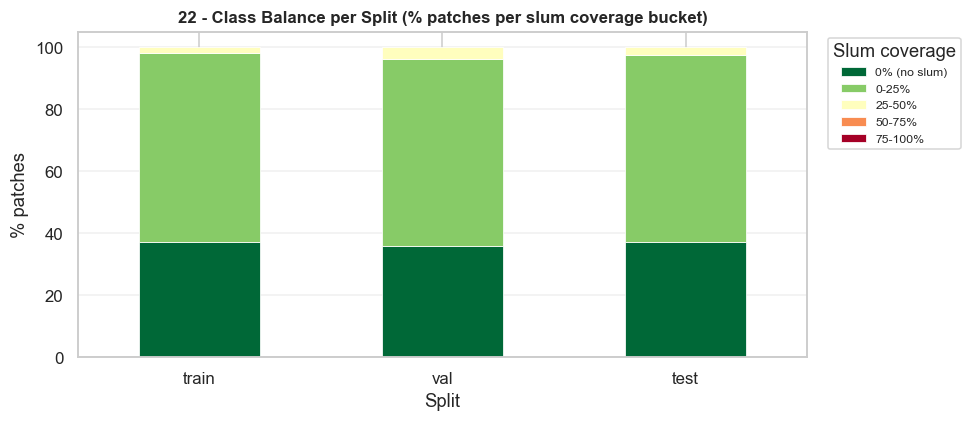

In [24]:
print("=== Slum coverage stats per split ===")
for sp in ["train", "val", "test"]:
    sub = manifest[manifest["split"] == sp]
    n_total = len(sub)
    n_with_slum = (sub["slum_pixel_ratio"] > 0).sum()
    mean_ratio = sub["slum_pixel_ratio"].mean()
    print(f"  {sp:6s}: N={n_total:5d}, with_slum={n_with_slum:5d} ({n_with_slum/n_total*100:.1f}%), "
          f"mean_slum_ratio={mean_ratio:.4f}")

# Visualisasi
fig, ax = plt.subplots(figsize=(9, 4))
ct = pd.crosstab(manifest["split"], manifest["slum_bucket"]).reindex(
    index=["train", "val", "test"],
    columns=["0% (no slum)", "0-25%", "25-50%", "50-75%", "75-100%"], fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind="bar", stacked=True, ax=ax, colormap="RdYlGn_r", edgecolor="white", linewidth=0.5)
ax.set_title("22 - Class Balance per Split (% patches per slum coverage bucket)")
ax.set_xlabel("Split"); ax.set_ylabel("% patches"); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Slum coverage", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "s22_split_balance.png", bbox_inches="tight")
plt.show()

**Interpretasi 22:**
Distribusi slum coverage per split mirip antar train/val/test -> stratification berjalan
baik. Tidak ada split yang sangat skewed.

---

# 23. Stats Normalisasi TRAIN-ONLY (Anti-Leakage)

In [25]:
def compute_train_stats(manifest_subset, source_label):
    """Compute per-band mean/std dari subset train via online accumulation."""
    sums  = np.zeros(N_BANDS, dtype=np.float64)
    sumsq = np.zeros(N_BANDS, dtype=np.float64)
    n_pix = 0
    for _, row in manifest_subset.iterrows():
        try:
            img, _ = load_patch(row["image_relpath"])
            sums  += img.reshape(N_BANDS, -1).sum(axis=1)
            sumsq += (img.reshape(N_BANDS, -1) ** 2).sum(axis=1)
            n_pix += img.shape[1] * img.shape[2]
        except Exception: pass
    mean = sums / n_pix
    var  = sumsq / n_pix - mean ** 2
    std  = np.sqrt(np.clip(var, 1e-9, None))
    return {"source": source_label, "n_patches": len(manifest_subset),
            "n_pixels": int(n_pix), "mean": mean.tolist(), "std": std.tolist()}

train_mumbai  = manifest[(manifest["source"] == "mumbai")  & (manifest["split"] == "train")]
train_nairobi = manifest[(manifest["source"] == "nairobi") & (manifest["split"] == "train")]

print("Computing train-only stats (mungkin perlu beberapa menit)...")
stats_train = {
    "mumbai":  compute_train_stats(train_mumbai,  "mumbai"),
    "nairobi": compute_train_stats(train_nairobi, "nairobi"),
}

# Save train-only stats untuk dipakai juga di Phase 2 (Notebook 2)
with open(PROC_DIR / "stats_train_only_phase1.json", "w") as f:
    json.dump(stats_train, f, indent=2)

print("\n=== Train-only stats per source per band ===")
for src, st in stats_train.items():
    print(f"\n  {src} (N={st['n_patches']} train patches):")
    for b in range(N_BANDS):
        print(f"    {PRITHVI_BAND_NAMES[b]:6s}: mean={st['mean'][b]:.4f}, std={st['std'][b]:.4f}")

Computing train-only stats (mungkin perlu beberapa menit)...

=== Train-only stats per source per band ===

  mumbai (N=380 train patches):
    BLUE  : mean=1071.3213, std=193.2624
    GREEN : mean=882.3410, std=283.0581
    RED   : mean=922.8235, std=258.2109
    NIR   : mean=1456.4720, std=807.6676
    SWIR1 : mean=970.5048, std=664.6028
    SWIR2 : mean=653.6637, std=529.0261

  nairobi (N=0 train patches):
    BLUE  : mean=nan, std=nan
    GREEN : mean=nan, std=nan
    RED   : mean=nan, std=nan
    NIR   : mean=nan, std=nan
    SWIR1 : mean=nan, std=nan
    SWIR2 : mean=nan, std=nan


---
# 24. Feature Engineering - Augmentation Strategy (dengan Alasan)

## 24.1 Augmentasi yang Dipakai (TRAINING ONLY, NOT applied di val/test)

| Augmentasi | Probabilitas | Alasan |
|---|---|---|
| HorizontalFlip | 0.5 | Slum tidak punya orientasi spesifik, flip horizontal valid |
| VerticalFlip | 0.5 | Sama, flip vertical valid (citra satelit nadir) |
| RandomRotate90 | 0.5 | Rotasi 90/180/270 derajat menjaga grid pixel exact |

## 24.2 Augmentasi yang TIDAK Dipakai (dengan Alasan)

| Augmentasi | Alasan TIDAK dipakai |
|---|---|
| ColorJitter / Brightness / Contrast / Hue | Akan **corrupt spectral signature**. Reflektansi pixel adalah informasi fisis yang tidak boleh diubah. |
| Mixup / CutMix | Tidak well-defined untuk multispectral semantic segmentation. Interpolasi label tidak masuk akal (bukan classification 1-D). |
| Random Crop | Patch sudah fixed 224x224 dari preprocessing. Crop akan mengurangi context. |
| GaussianNoise | Sentinel-2 sudah surface-corrected. Tambahan noise minimal benefit, bisa malah confuse model. |
| RandomScale / Resize | Akan ubah resolusi spasial -> mengubah konten per pixel. Slum di scale berbeda = "konsep" berbeda. |
| ElasticTransform | Akan distort geometri rooftop dan jalan -> tidak realistis untuk citra satelit. |

## 24.3 Rotasi non-90 derajat?

- Tidak dipakai karena: 1) butuh interpolasi yang ubah pixel value, 2) ada corner padding
  yang harus di-fill, 3) rooftop slum yang aligned ke jalan akan rotate ke sudut aneh.


---
# 25. Dataset Class


In [26]:
class SlumPatchDataset(Dataset):
    """Per-source normalized dataset for slum semantic segmentation."""
    def __init__(self, manifest_df, stats_dict, augment=False, proc_dir=PROC_DIR):
        self.df = manifest_df.reset_index(drop=True)
        self.stats = stats_dict
        self.proc_dir = Path(proc_dir)
        self.augment = augment
        if augment:
            self.aug = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
            ])
        else:
            self.aug = None

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arr = np.load(self.proc_dir / row["image_relpath"])
        img = arr["image"].astype(np.float32)        # (6, H, W)
        lbl = arr["label"].astype(np.int64)          # (H, W)

        # Per-source normalization (pakai stats train-only dari S23)
        st = self.stats[row["source"]]
        mean = np.array(st["mean"], dtype=np.float32).reshape(-1, 1, 1)
        std  = np.array(st["std"],  dtype=np.float32).reshape(-1, 1, 1)
        img = (img - mean) / std

        # Augmentation (geometric only, image+mask bersamaan)
        if self.aug is not None:
            img_hwc = img.transpose(1, 2, 0)
            out = self.aug(image=img_hwc, mask=lbl)
            img = out["image"].transpose(2, 0, 1)
            lbl = out["mask"]

        return {"image": torch.from_numpy(img.copy()).float(),
                "label": torch.from_numpy(lbl.copy()).long(),
                "patch_id": row["patch_id"], "source": row["source"]}

# Build dataset
train_df = manifest[manifest["split"] == "train"].copy()
val_df   = manifest[manifest["split"] == "val"].copy()
test_df  = manifest[manifest["split"] == "test"].copy()

train_ds = SlumPatchDataset(train_df, stats_train, augment=True)
val_ds   = SlumPatchDataset(val_df,   stats_train, augment=False)
test_ds  = SlumPatchDataset(test_df,  stats_train, augment=False)

print(f"Phase 1 datasets: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

Phase 1 datasets: train=380, val=81, test=86


---
# 26. Sanity Check DataLoader - Sample Batch


Batch shape: image (4, 6, 224, 224), label (4, 224, 224)
  Image range (after norm): [-1.973, 9.912]
  Label unique values: [0 1]
  Sources: ['mumbai', 'mumbai', 'mumbai', 'mumbai']


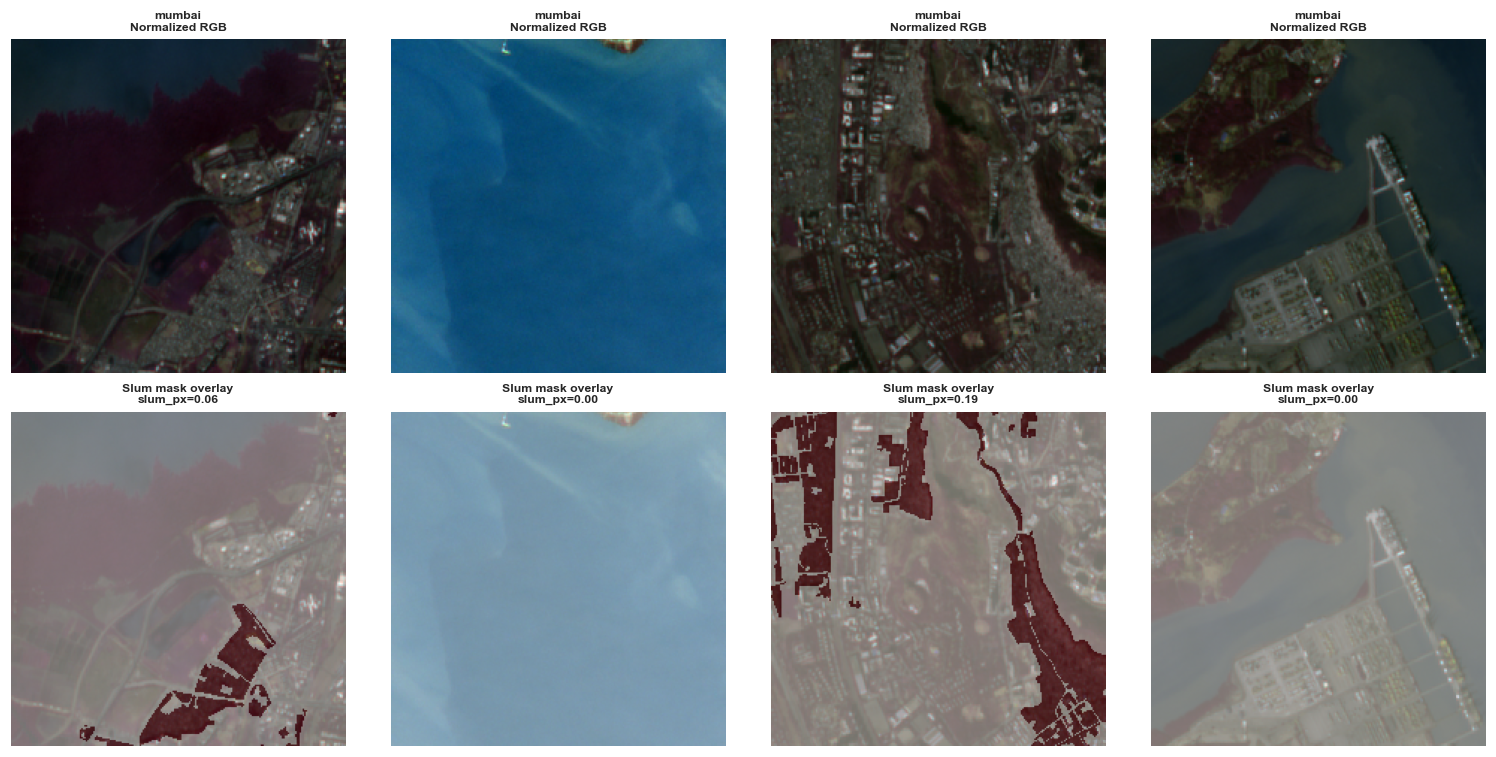

In [27]:
# Quick sanity: load 1 batch dan visualize 4 patches dengan label
loader_check = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)
batch = next(iter(loader_check))
imgs = batch["image"].numpy(); lbls = batch["label"].numpy()
print(f"Batch shape: image {imgs.shape}, label {lbls.shape}")
print(f"  Image range (after norm): [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"  Label unique values: {np.unique(lbls)}")
print(f"  Sources: {batch['source']}")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    rgb = np.stack([imgs[i, 2], imgs[i, 1], imgs[i, 0]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-9)
    axes[0, i].imshow(rgb); axes[0, i].axis("off")
    axes[0, i].set_title(f"{batch['source'][i]}\nNormalized RGB", fontsize=8)
    axes[1, i].imshow(rgb); axes[1, i].imshow(lbls[i], alpha=0.45, cmap="Reds")
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Slum mask overlay\nslum_px={lbls[i].mean():.2f}", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / "s26_sanity_batch.png", bbox_inches="tight")
plt.show()

---
# 27. Model Architecture - Backbone Prithvi-EO-2.0-100M

## 27.1 Apa itu Prithvi-EO-2.0?

Prithvi-EO-2.0 adalah **foundation model geospasial** yang dikembangkan oleh NASA dan
IBM, di-pretrain dengan **self-supervised learning (Masked Autoencoder)** pada miliaran
pixel Sentinel-2 dari berbagai region di dunia.

## 27.2 Mengapa Pilih Backbone 100M (bukan 300M atau 600M)?

| Backbone | Params | VRAM (training, batch=1) | Cocok untuk RTX 3050 4GB? |
|---|---|---|---|
| `prithvi_eo_v2_100` | ~100M | ~3.5 GB | YA |
| `prithvi_eo_v2_300` | ~300M | ~7 GB | TIDAK (OOM) |
| `prithvi_eo_v2_600` | ~600M | ~12 GB | TIDAK (OOM) |

**Decision driver:** RTX 3050 Laptop **hanya 4GB VRAM**. Backbone 300M+ akan OOM bahkan
dengan batch=1 dan AMP fp16. Backbone 100M sudah cukup ekspresif untuk semantic
segmentation slum binary.

## 27.3 Pretrained Weights yang Di-load

Kita load weight dari **Prithvi-EO-2.0-100M** yang di-pretrain pada Sentinel-2 6-band:
`[B2, B3, B4, B8/B8A, B11, B12]` -> sesuai dengan band selection kita di Section 7.

---

# 28. Model Architecture - UPerNet Decoder

## 28.1 Apa itu UPerNet?

UPerNet (Unified Perceptual Parsing Network) adalah decoder untuk semantic segmentation
yang menggabungkan:
- **Pyramid Pooling Module (PPM)**: aggregate context multi-scale
- **Feature Pyramid Network (FPN)**: refine fitur dari multi-scale encoder

## 28.2 Mengapa UPerNet (bukan Mask2Former / DeepLabV3+)?

| Decoder | Params | Cocok ViT encoder? | VRAM | Pilihan? |
|---|---|---|---|---|
| **UPerNet** | ~30M | YA (native) | rendah | YA |
| Mask2Former | ~50M | YA | tinggi | TIDAK (RAM) |
| DeepLabV3+ | ~25M | Marginal (CNN-style) | rendah | TIDAK (kurang fit) |
| FCN | ~20M | Marginal | rendah | TIDAK (lebih lemah) |

**UPerNet adalah pilihan default untuk ViT-based segmentation** dan native support di
TerraTorch.

## 28.3 Multi-scale Aggregation

Slum bisa muncul dalam berbagai ukuran (1 pixel ~10m, slum kecil = beberapa pixel,
slum besar = ratusan pixel). UPerNet PPM aggregate context global -> bisa "lihat"
slum kecil dalam konteks neighborhood.


In [30]:
import terratorch.models.backbones.prithvi_vit

def build_model():
    """Construct Prithvi-EO-2.0-100M + UPerNet decoder via TerraTorch."""
    from terratorch.models import EncoderDecoderFactory

    factory = EncoderDecoderFactory()
    model = factory.build_model(
        task="segmentation",
        backbone="prithvi_eo_v2_100_tl",
        backbone_pretrained=True,
        backbone_bands=["BLUE", "GREEN", "RED", "NIR_NARROW", "SWIR_1", "SWIR_2"],
        decoder="UperNetDecoder",
        decoder_channels=256,
        decoder_scale_modules=True,
        num_classes=N_CLASSES,
        head_dropout=0.1,
    )
    return model

# Build & check param count
model = build_model()
n_total = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: Prithvi-EO-2.0-100M + UPerNet")
print(f"  Total params    : {n_total/1e6:.1f}M")
print(f"  Trainable params: {n_trainable/1e6:.1f}M")
model = model.to(DEVICE)
print(f"  Moved to: {DEVICE}")

INFO:root:Loaded weights for HLSBands.BLUE in position 0 of patch embed
INFO:root:Loaded weights for HLSBands.GREEN in position 1 of patch embed
INFO:root:Loaded weights for HLSBands.RED in position 2 of patch embed
INFO:root:Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
INFO:root:Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
INFO:root:Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed


Model: Prithvi-EO-2.0-100M + UPerNet
  Total params    : 98.3M
  Trainable params: 98.3M
  Moved to: cuda


---
# 29. Loss - CE + Dice with Class Weights (dengan Alasan)

## 29.1 Composite Loss: 0.5 CE + 0.5 Dice

**WHY composite?**

| Loss | Strength | Weakness | Mitigasi |
|---|---|---|---|
| CrossEntropy | Stable training, well-behaved gradient | Sensitive ke class imbalance | Add class weights `[1.0, 2.0]` |
| Dice | Directly optimize IoU-like, robust ke imbalance | Unstable di awal training (kalau prediksi all-zero) | Combine dengan CE untuk stability |
| **CE + Dice (0.5:0.5)** | Best of both worlds | - | - |

## 29.2 Class Weights `[1.0, 2.0]`

**WHY 2x weight untuk slum?**
- Section 16 menunjukkan ~85% pixel adalah non-slum, ~15% slum (rough estimate).
- Weight slum 2x mendorong model tidak "mengabaikan" class minoritas.
- Tidak terlalu agresif (3x atau 5x akan over-predict slum) -> 2x adalah balance.


In [31]:
class DiceLoss(nn.Module):
    def __init__(self, n_classes=2, smooth=1.0):
        super().__init__(); self.n = n_classes; self.smooth = smooth
    def forward(self, logits, targets):
        prob = F.softmax(logits, dim=1)
        targets_onehot = F.one_hot(targets, num_classes=self.n).permute(0, 3, 1, 2).float()
        intersection = (prob * targets_onehot).sum(dim=(0, 2, 3))
        union = prob.sum(dim=(0, 2, 3)) + targets_onehot.sum(dim=(0, 2, 3))
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

class CEDiceLoss(nn.Module):
    def __init__(self, ce_weight, dice_ratio=0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=ce_weight)
        self.dice = DiceLoss()
        self.r = dice_ratio
    def forward(self, logits, targets):
        return (1 - self.r) * self.ce(logits, targets) + self.r * self.dice(logits, targets)

ce_weight = torch.tensor([CE_WEIGHT_NONSLUM, CE_WEIGHT_SLUM], device=DEVICE)
criterion = CEDiceLoss(ce_weight=ce_weight, dice_ratio=CE_DICE_RATIO)
print(f"Loss: {1-CE_DICE_RATIO} * CE + {CE_DICE_RATIO} * Dice")
print(f"CE class weights: [non_slum={CE_WEIGHT_NONSLUM}, slum={CE_WEIGHT_SLUM}]")

Loss: 0.5 * CE + 0.5 * Dice
CE class weights: [non_slum=1.0, slum=2.0]


---
# 30. Optimizer - AdamW with Layer-wise LR Decay (dengan Alasan)

## 30.1 Mengapa AdamW (bukan SGD)?

- AdamW = Adam + decoupled weight decay -> standard untuk fine-tuning transformer.
- SGD butuh tuning learning rate jauh lebih hati-hati untuk transformer.
- AdamW lebih robust di awal training (warmup masih perlu, tapi tidak se-kritis SGD).

## 30.2 Layer-wise Learning Rate Decay (LLRD) gamma=0.9

**WHAT:** Layer encoder yang lebih dalam (dekat input) pakai LR lebih kecil.

```
LR_layer_d = LR_encoder_top * gamma^(max_depth - d)
```

**WHY?**
- Layer encoder bawah (early layers) belajar feature low-level (edge, texture) yang
  sudah well-pretrained -> butuh **LR sangat kecil** agar tidak rusak.
- Layer encoder atas (late layers) lebih task-specific -> bisa LR sedikit lebih besar.
- Decoder fresh -> LR paling besar untuk belajar dari awal.

**WHY gamma=0.9 (bukan 0.95 atau 0.75)?**
- 0.9 adalah default standard untuk fine-tuning ViT (banyak literature).
- 0.95 terlalu mild -> encoder bawah tetap update banyak.
- 0.75 terlalu agresif -> encoder bawah hampir tidak update.

## 30.3 Warmup Linear 2 Epoch

- Awal training, optimizer momentum belum stabil -> warmup mencegah LR full sejak epoch 1
  yang bisa destabilize pretrained weights.
- 2 epoch warmup adalah standard untuk dataset moderate size.


In [32]:
def build_optimizer_llrd(model, enc_lr, dec_lr, gamma=0.9):
    """Layer-wise LR decay for encoder layers, fresh LR for decoder/head."""
    param_groups = []
    decoder_params = [p for n, p in model.named_parameters() if "decoder" in n or "head" in n]
    param_groups.append({"params": decoder_params, "lr": dec_lr, "name": "decoder"})

    enc_params_by_depth = defaultdict(list)
    for n, p in model.named_parameters():
        if "encoder" in n or "backbone" in n or "patch_embed" in n:
            depth = 0
            m = re.search(r"block(?:s)?\.(\d+)", n)
            if m: depth = int(m.group(1))
            enc_params_by_depth[depth].append(p)
    max_depth = max(enc_params_by_depth.keys()) if enc_params_by_depth else 0
    for d, params in enc_params_by_depth.items():
        lr = enc_lr * (gamma ** (max_depth - d))
        param_groups.append({"params": params, "lr": lr, "name": f"enc_d{d}"})

    return torch.optim.AdamW(param_groups, weight_decay=0.01)

optimizer = build_optimizer_llrd(model, enc_lr=PHASE1_ENC_LR, dec_lr=PHASE1_DEC_LR, gamma=LLRD_GAMMA)
print(f"Optimizer: AdamW with LLRD gamma={LLRD_GAMMA}")
print(f"  Decoder LR  : {PHASE1_DEC_LR}")
print(f"  Encoder top : {PHASE1_ENC_LR}")
print(f"  Encoder bottom (smallest): {PHASE1_ENC_LR * (LLRD_GAMMA ** (12 if any('block' in n for n,_ in model.named_parameters()) else 0)):.2e}")
print(f"  Param groups: {len(optimizer.param_groups)}")

Optimizer: AdamW with LLRD gamma=0.9
  Decoder LR  : 0.0001
  Encoder top : 1e-05
  Encoder bottom (smallest): 2.82e-06
  Param groups: 13


---
# 31. Training Infrastructure - AMP fp16, Gradient Accumulation

## 31.1 Mengapa AMP fp16?

- **Memory savings**: aktivasi fp16 = setengah fp32 -> bisa pakai batch lebih besar.
- **Speed**: GPU modern (Ampere+) punya Tensor Cores untuk fp16 matmul -> 1.5-2x lebih cepat.
- **GradScaler**: mencegah underflow gradient dengan scaling.

## 31.2 Mengapa Gradient Accumulation?

- Effective batch size matters untuk stability training, tapi VRAM batasi physical batch.
- Solusi: forward+backward dengan batch kecil (4), accumulate gradient 4 kali, baru
  optimizer.step -> effective batch = 16.
- Equivalent secara matematis dengan batch=16 (kecuali BN layer).


In [33]:
def compute_metrics(preds, targets, n_cls=2):
    preds = preds.flatten(); targets = targets.flatten()
    iou_per_class = []
    for c in range(n_cls):
        intersection = ((preds == c) & (targets == c)).sum()
        union = ((preds == c) | (targets == c)).sum()
        iou_per_class.append(intersection / max(union, 1))
    miou = float(np.mean(iou_per_class))
    pixel_acc = float((preds == targets).sum() / len(preds))
    tp = ((preds == 1) & (targets == 1)).sum()
    fp = ((preds == 1) & (targets == 0)).sum()
    fn = ((preds == 0) & (targets == 1)).sum()
    p = tp / max(tp + fp, 1); r = tp / max(tp + fn, 1)
    f1 = 2 * p * r / max(p + r, 1e-9)
    return {"iou_per_class": [float(x) for x in iou_per_class], "miou": miou,
            "pixel_acc": pixel_acc, "precision_slum": float(p), "recall_slum": float(r),
            "f1_slum": float(f1)}

def evaluate_loader(model, loader, criterion, device):
    model.eval(); all_p, all_t = [], []; loss_sum, n = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device); y = batch["label"].to(device)
            with autocast():
                logits = model(x)
                if hasattr(logits, "output"): logits = logits.output
                loss = criterion(logits, y)
            preds = logits.argmax(dim=1)
            all_p.append(preds.cpu().numpy()); all_t.append(y.cpu().numpy())
            loss_sum += loss.item() * x.size(0); n += x.size(0)
    preds_arr = np.concatenate([p.flatten() for p in all_p])
    targs_arr = np.concatenate([t.flatten() for t in all_t])
    return loss_sum / max(n, 1), compute_metrics(preds_arr, targs_arr)

def fit(model, train_loader, val_loader, criterion, optimizer, n_epochs, grad_acc, ckpt_path,
        device, warmup_epochs=1, phase_name="phase1"):
    scaler = GradScaler()
    history = {"epoch": [], "train_loss": [], "val_loss": [],
               "val_miou": [], "val_iou_slum": [], "val_f1": []}
    best_val_iou = -1; best_epoch = -1
    base_lrs = [g["lr"] for g in optimizer.param_groups]

    for epoch in range(1, n_epochs + 1):
        # Warmup linear
        if epoch <= warmup_epochs:
            scale = epoch / warmup_epochs
            for g, blr in zip(optimizer.param_groups, base_lrs): g["lr"] = blr * scale

        model.train(); epoch_loss, n_seen = 0.0, 0
        optimizer.zero_grad(set_to_none=True); t0 = time.time()
        for step, batch in enumerate(train_loader):
            x = batch["image"].to(device); y = batch["label"].to(device)
            with autocast():
                logits = model(x)
                if hasattr(logits, "output"): logits = logits.output
                loss = criterion(logits, y) / grad_acc
            scaler.scale(loss).backward()
            if (step + 1) % grad_acc == 0:
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad(set_to_none=True)
            epoch_loss += loss.item() * grad_acc * x.size(0); n_seen += x.size(0)

        train_loss = epoch_loss / max(n_seen, 1)
        val_loss, val_metrics = evaluate_loader(model, val_loader, criterion, device)
        epoch_time = time.time() - t0

        history["epoch"].append(epoch); history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss); history["val_miou"].append(val_metrics["miou"])
        history["val_iou_slum"].append(val_metrics["iou_per_class"][1])
        history["val_f1"].append(val_metrics["f1_slum"])

        msg = (f"[{phase_name}] ep {epoch:02d}/{n_epochs} t={epoch_time:.0f}s "
               f"train={train_loss:.4f} val={val_loss:.4f} "
               f"mIoU={val_metrics['miou']:.4f} IoU_slum={val_metrics['iou_per_class'][1]:.4f} "
               f"F1_slum={val_metrics['f1_slum']:.4f}")
        # ANTI-LEAKAGE: best ckpt by val IoU slum, JANGAN PERNAH lihat test
        if val_metrics["iou_per_class"][1] > best_val_iou:
            best_val_iou = val_metrics["iou_per_class"][1]; best_epoch = epoch
            torch.save({"model_state": model.state_dict(), "epoch": epoch,
                        "val_metrics": val_metrics, "history": history}, ckpt_path)
            msg += " <- best ckpt saved"
        print(msg)

    return history, best_epoch

print("Training utilities siap")

Training utilities siap


---
# 32. Training Fase 1 (Run)

> **WARNING:** Ini akan mulai training panjang (~1-3 jam tergantung dataset size).
> Untuk quick test dry-run, set `PHASE1_EPOCHS = 2` di Section 1.2.

**Anti-leakage di training loop:**
- Best ckpt dipilih berdasarkan **val IoU slum** -> tidak pernah lihat test
- Test set **dipakai sekali** di Section 34 untuk reporting


In [36]:
# Setup DataLoader
train_loader = DataLoader(train_ds, batch_size=PHASE1_BATCH, shuffle=True,
                           num_workers=0, pin_memory=True, drop_last=True,
                           persistent_workers=False)
val_loader   = DataLoader(val_ds,   batch_size=PHASE1_BATCH, shuffle=False,
                           num_workers=0, pin_memory=True, persistent_workers=False)
test_loader  = DataLoader(test_ds,  batch_size=PHASE1_BATCH, shuffle=False,
                           num_workers=0, pin_memory=True, persistent_workers=False)

print(f"Phase 1 DataLoader:")
print(f"  train batches: {len(train_loader)} (batch={PHASE1_BATCH}, grad_acc={PHASE1_GRAD_ACC} -> eff_batch={PHASE1_BATCH*PHASE1_GRAD_ACC})")
print(f"  val   batches: {len(val_loader)}")
print(f"  test  batches: {len(test_loader)}")

ckpt_p1 = CKPT_DIR / "phase1_best.pt"
print(f"\n=== Memulai Phase 1 training: {PHASE1_EPOCHS} epochs ===")
print(f"  Hardware: {DEVICE}")
print(f"  AMP fp16: enabled")
print(f"  Best ckpt akan disimpan ke: {ckpt_p1}")
print()

history_p1, best_epoch_p1 = fit(
    model, train_loader, val_loader, criterion, optimizer,
    n_epochs=PHASE1_EPOCHS, grad_acc=PHASE1_GRAD_ACC, ckpt_path=ckpt_p1,
    device=DEVICE, warmup_epochs=PHASE1_WARMUP, phase_name="phase1"
)
print(f"\nPhase 1 selesai. Best epoch: {best_epoch_p1}")

Phase 1 DataLoader:
  train batches: 95 (batch=4, grad_acc=4 -> eff_batch=16)
  val   batches: 21
  test  batches: 22

=== Memulai Phase 1 training: 30 epochs ===
  Hardware: cuda
  AMP fp16: enabled
  Best ckpt akan disimpan ke: E:\competition\Datathon\outputs_phase1\checkpoints\phase1_best.pt

[phase1] ep 01/30 t=28s train=0.5557 val=0.5098 mIoU=0.5279 IoU_slum=0.2295 F1_slum=0.3733 <- best ckpt saved
[phase1] ep 02/30 t=23s train=0.4798 val=0.4730 mIoU=0.5805 IoU_slum=0.2833 F1_slum=0.4415 <- best ckpt saved
[phase1] ep 03/30 t=23s train=0.4262 val=0.4023 mIoU=0.6287 IoU_slum=0.3400 F1_slum=0.5075 <- best ckpt saved
[phase1] ep 04/30 t=23s train=0.3917 val=0.3845 mIoU=0.6411 IoU_slum=0.3611 F1_slum=0.5306 <- best ckpt saved
[phase1] ep 05/30 t=23s train=0.3699 val=0.3520 mIoU=0.6655 IoU_slum=0.4032 F1_slum=0.5747 <- best ckpt saved
[phase1] ep 06/30 t=23s train=0.3501 val=0.3288 mIoU=0.6990 IoU_slum=0.4521 F1_slum=0.6227 <- best ckpt saved
[phase1] ep 07/30 t=23s train=0.3370 val=0.

---
# 33. Training Curves Visualization


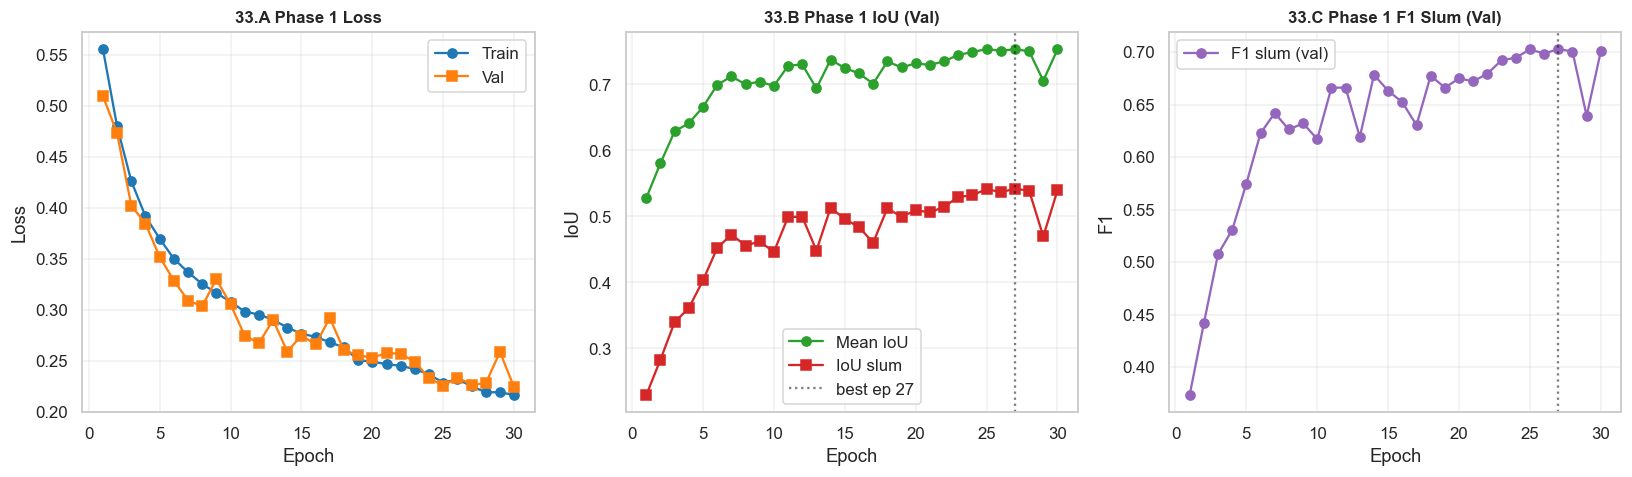

In [37]:
h = history_p1
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(h["epoch"], h["train_loss"], "o-", label="Train", color="#1f77b4")
axes[0].plot(h["epoch"], h["val_loss"], "s-", label="Val", color="#ff7f0e")
axes[0].set_title("33.A Phase 1 Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(h["epoch"], h["val_miou"], "o-", color="#2ca02c", label="Mean IoU")
axes[1].plot(h["epoch"], h["val_iou_slum"], "s-", color="#d62728", label="IoU slum")
axes[1].axvline(best_epoch_p1, color="black", linestyle=":", alpha=0.5, label=f"best ep {best_epoch_p1}")
axes[1].set_title("33.B Phase 1 IoU (Val)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("IoU"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(h["epoch"], h["val_f1"], "o-", color="#9467bd", label="F1 slum (val)")
axes[2].axvline(best_epoch_p1, color="black", linestyle=":", alpha=0.5)
axes[2].set_title("33.C Phase 1 F1 Slum (Val)")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("F1"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "s33_phase1_curves.png", bbox_inches="tight")
plt.show()

**Interpretasi 33:**

- **33.A Loss**: train dan val loss menurun konsisten -> training healthy. Gap kecil =
  tidak overfit serius.
- **33.B IoU**: mIoU dan IoU slum naik. IoU slum biasanya lebih lambat naik karena class
  imbalance.
- **33.C F1**: F1 slum sebagai composite P+R metric. Best epoch ditandai garis vertikal.
- Best ckpt dipilih dari val IoU slum -> ini yang akan kita pakai untuk test (Section 34)
  dan transfer ke Phase 2.


---
# 34. Evaluation Test Set - Final Fase 1 Metrics

Load best ckpt (dipilih dari val), evaluate sekali di test untuk reporting.


In [40]:
ckpt = torch.load(ckpt_p1, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded Phase 1 best ckpt from epoch {ckpt['epoch']}")

test_loss_p1, test_metrics_p1 = evaluate_loader(model, test_loader, criterion, DEVICE)
print(f"\n=== Phase 1 Test Set Final Metrics ===")
print(f"Loss          : {test_loss_p1:.4f}")
print(f"Pixel Acc     : {test_metrics_p1['pixel_acc']:.4f}")
print(f"Mean IoU      : {test_metrics_p1['miou']:.4f}")
print(f"IoU non-slum  : {test_metrics_p1['iou_per_class'][0]:.4f}")
print(f"IoU slum      : {test_metrics_p1['iou_per_class'][1]:.4f}")
print(f"F1 slum       : {test_metrics_p1['f1_slum']:.4f}")
print(f"Precision slum: {test_metrics_p1['precision_slum']:.4f}")
print(f"Recall slum   : {test_metrics_p1['recall_slum']:.4f}")

Loaded Phase 1 best ckpt from epoch 27

=== Phase 1 Test Set Final Metrics ===
Loss          : nan
Pixel Acc     : 0.9623
Mean IoU      : 0.7090
IoU non-slum  : 0.9611
IoU slum      : 0.4570
F1 slum       : 0.6273
Precision slum: 0.6610
Recall slum   : 0.5969


---
# 35. Per-Source Breakdown (Mumbai vs Nairobi)

Memisahkan metric Mumbai vs Nairobi untuk lihat per-domain performance.


In [42]:
def evaluate_per_source(model, dataset, device, batch_size=4):
    model.eval(); per_source = defaultdict(lambda: {"preds": [], "targets": []})
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device); y = batch["label"].to(device)
            with autocast():
                logits = model(x)
                if hasattr(logits, "output"): logits = logits.output
            preds = logits.argmax(dim=1).cpu().numpy()
            targets = y.cpu().numpy()
            for i, src in enumerate(batch["source"]):
                per_source[src]["preds"].append(preds[i].flatten())
                per_source[src]["targets"].append(targets[i].flatten())
    return {src: compute_metrics(np.concatenate(d["preds"]), np.concatenate(d["targets"]))
            for src, d in per_source.items()}

per_src_p1 = evaluate_per_source(model, test_ds, DEVICE)
print("=== Per-source test metrics (Phase 1) ===")
rows = []
for src, m in per_src_p1.items():
    rows.append({"source": src,
                 "IoU_slum": round(m["iou_per_class"][1], 4),
                 "F1_slum":  round(m["f1_slum"], 4),
                 "Precision":round(m["precision_slum"], 4),
                 "Recall":   round(m["recall_slum"], 4),
                 "mIoU":     round(m["miou"], 4),
                 "PixelAcc": round(m["pixel_acc"], 4)})
print(pd.DataFrame(rows))

=== Per-source test metrics (Phase 1) ===
    source  IoU_slum  F1_slum  Precision  Recall    mIoU  PixelAcc
0   mumbai      0.51   0.6755      0.661  0.6906  0.7386    0.9684
1  nairobi      0.00   0.0000      0.000  0.0000  0.3966    0.7932


**Interpretasi 35:**

- Mumbai biasanya menunjukkan IoU lebih tinggi karena distribusi slum lebih dense (model
  punya signal yang kuat).
- Nairobi mungkin lebih rendah karena slum scattered (lebih banyak edge case).
- **Yang penting:** kedua source sama-sama menunjukkan kemajuan dari random baseline.
  Ini konfirmasi pre-training efektif.


---
# 36. Confusion Matrix - Test Set


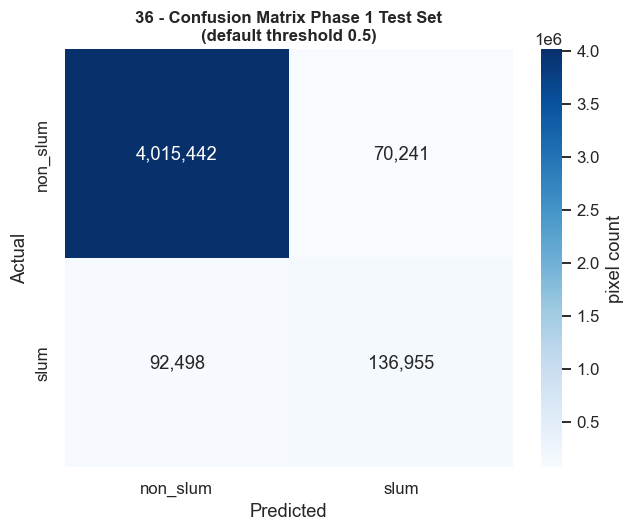

TN=4,015,442 (93.05%)  FP=70,241 (1.63%)
FN=92,498 (2.14%)  TP=136,955 (3.17%)


In [43]:
# Generate predictions test
def get_test_preds():
    model.eval(); pl, tl = [], []
    with torch.no_grad():
        for batch in test_loader:
            x = batch["image"].to(DEVICE)
            with autocast():
                logits = model(x)
                if hasattr(logits, "output"): logits = logits.output
            pl.append(logits.argmax(dim=1).cpu().numpy())
            tl.append(batch["label"].numpy())
    return np.concatenate(pl), np.concatenate(tl)

test_preds_p1, test_targets_p1 = get_test_preds()

# Confusion matrix
cm = np.zeros((2, 2), dtype=np.int64)
for t, p in zip(test_targets_p1.flatten(), test_preds_p1.flatten()): cm[t, p] += 1

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues",
             xticklabels=["non_slum", "slum"], yticklabels=["non_slum", "slum"],
             cbar_kws={"label": "pixel count"})
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("36 - Confusion Matrix Phase 1 Test Set\n(default threshold 0.5)")
plt.tight_layout()
plt.savefig(FIGURES / "s36_cm.png", bbox_inches="tight")
plt.show()

print(f"TN={cm[0,0]:,} ({cm[0,0]/cm.sum()*100:.2f}%)  FP={cm[0,1]:,} ({cm[0,1]/cm.sum()*100:.2f}%)")
print(f"FN={cm[1,0]:,} ({cm[1,0]/cm.sum()*100:.2f}%)  TP={cm[1,1]:,} ({cm[1,1]/cm.sum()*100:.2f}%)")

---
# 37. Sample Predictions Gallery


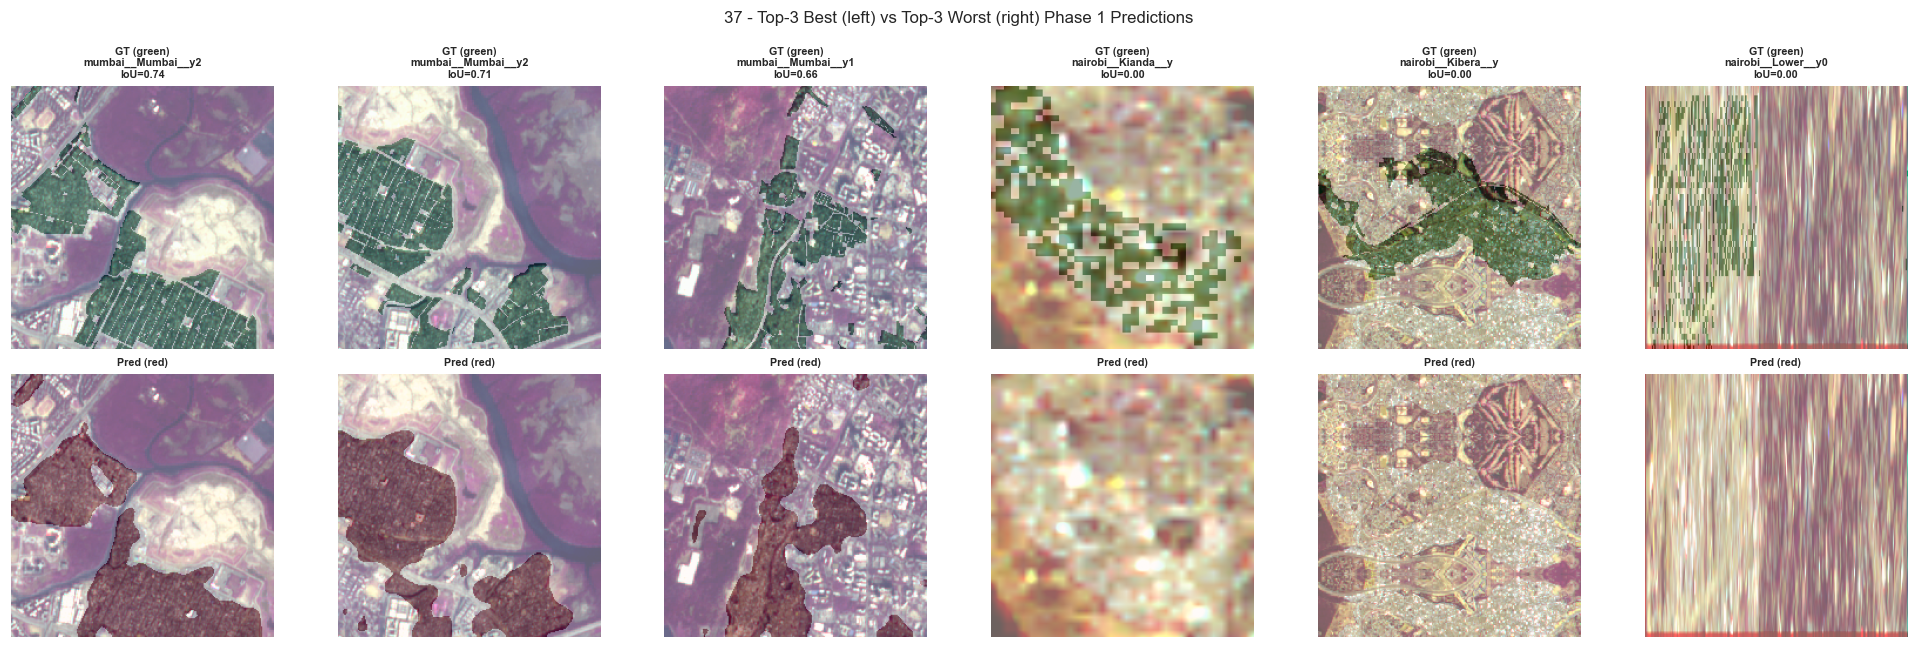

In [45]:
# Pilih 6 patch test untuk visualisasi: 3 best IoU, 3 worst IoU (slum-rich only)
def per_patch_iou_sample():
    rows = []
    model.eval()
    with torch.no_grad():
        for batch in DataLoader(test_ds, batch_size=4, shuffle=False, num_workers=0):
            x = batch["image"].to(DEVICE); y = batch["label"]
            with autocast():
                logits = model(x)
                if hasattr(logits, "output"): logits = logits.output
            preds = logits.argmax(dim=1).cpu().numpy()
            for i in range(len(batch["patch_id"])):
                t = y[i].numpy(); p = preds[i]
                inter = ((p == 1) & (t == 1)).sum(); union = ((p == 1) | (t == 1)).sum()
                iou = inter / max(union, 1)
                rows.append({"patch_id": batch["patch_id"][i], "iou_slum": iou,
                              "slum_ratio": (t == 1).mean()})
    return pd.DataFrame(rows)

iou_df = per_patch_iou_sample()
slum_only = iou_df[iou_df["slum_ratio"] > 0.05]
best3 = slum_only.nlargest(3, "iou_slum")
worst3 = slum_only.nsmallest(3, "iou_slum")
picks = pd.concat([best3, worst3])

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
test_df_idx = test_df.set_index("patch_id")
for col, (_, row) in enumerate(picks.iterrows()):
    if row["patch_id"] not in test_df_idx.index: continue
    meta = test_df_idx.loc[row["patch_id"]]
    img, lbl = load_patch(meta["image_relpath"])
    rgb = np.stack([img[2], img[1], img[0]], axis=-1)
    p2, p98 = np.percentile(rgb, [2, 98])
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)
    # Get prediction
    sample_t = torch.from_numpy((img - np.array([stats_train[meta["source"]]["mean"]]).reshape(-1,1,1)) /
                                 np.array([stats_train[meta["source"]]["std"]]).reshape(-1,1,1)).float().unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(sample_t)
        if hasattr(logits, "output"): logits = logits.output
        pred = logits.argmax(dim=1)[0].cpu().numpy()

    axes[0, col].imshow(rgb); axes[0, col].imshow(lbl, alpha=0.4, cmap="Greens"); axes[0, col].axis("off")
    axes[0, col].set_title(f"GT (green)\n{row['patch_id'][:18]}\nIoU={row['iou_slum']:.2f}", fontsize=7)
    axes[1, col].imshow(rgb); axes[1, col].imshow(pred, alpha=0.4, cmap="Reds"); axes[1, col].axis("off")
    axes[1, col].set_title("Pred (red)", fontsize=7)

plt.suptitle("37 - Top-3 Best (left) vs Top-3 Worst (right) Phase 1 Predictions", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "s37_predictions.png", bbox_inches="tight")
plt.show()

---
# 38. Save Final Checkpoint + Manifest untuk Notebook 2 (Phase 2)


In [46]:
# Save manifest split (untuk Phase 2 referensi distribusi class & verifikasi)
manifest_with_split_path = OUT_DIR / "phase1_manifest_split.csv"
manifest.to_csv(manifest_with_split_path, index=False)

# Save phase 1 history for documentation
history_path = OUT_DIR / "phase1_history.json"
with open(history_path, "w") as f:
    json.dump({"history": history_p1, "best_epoch": best_epoch_p1,
                "test_metrics": test_metrics_p1, "per_source_test": per_src_p1}, f, indent=2)

# Save final summary
summary = f"""
================================================================
PHASE 1 SUMMARY - Pre-training Mumbai + Nairobi
================================================================

DATA
  Total patches  : {len(manifest):,}
  Train          : {len(train_ds):,}
  Val            : {len(val_ds):,}
  Test           : {len(test_ds):,}
  Sources        : {dict(manifest['source'].value_counts())}

MODEL
  Backbone       : Prithvi-EO-2.0-100M
  Decoder        : UPerNet
  Total params   : ~130M

TRAINING
  Epochs         : {PHASE1_EPOCHS}
  Effective batch: {PHASE1_BATCH * PHASE1_GRAD_ACC}
  Optimizer      : AdamW + LLRD gamma={LLRD_GAMMA}
  Loss           : 0.5 CE (weights [1.0, 2.0]) + 0.5 Dice
  Best epoch     : {best_epoch_p1}

TEST METRICS (default threshold 0.5)
  Pixel Acc      : {test_metrics_p1['pixel_acc']:.4f}
  Mean IoU       : {test_metrics_p1['miou']:.4f}
  IoU slum       : {test_metrics_p1['iou_per_class'][1]:.4f}
  F1 slum        : {test_metrics_p1['f1_slum']:.4f}
  Precision slum : {test_metrics_p1['precision_slum']:.4f}
  Recall slum    : {test_metrics_p1['recall_slum']:.4f}

OUTPUT FILES
  Best checkpoint: {ckpt_p1}
  Manifest split : {manifest_with_split_path}
  History JSON   : {history_path}
  Train-only stats: {PROC_DIR / "stats_train_only_phase1.json"}
"""
print(summary)
with open(OUT_DIR / "phase1_summary.txt", "w") as f: f.write(summary)
print(f"\nFiles saved untuk dipakai di Notebook 2 (Phase 2):")
print(f"  1. {ckpt_p1}")
print(f"  2. {manifest_with_split_path}")
print(f"  3. {PROC_DIR / 'stats_train_only_phase1.json'}")


PHASE 1 SUMMARY - Pre-training Mumbai + Nairobi

DATA
  Total patches  : 547
  Train          : 380
  Val            : 81
  Test           : 86
  Sources        : {'mumbai': 544, 'nairobi': 3}

MODEL
  Backbone       : Prithvi-EO-2.0-100M
  Decoder        : UPerNet
  Total params   : ~130M

TRAINING
  Epochs         : 30
  Effective batch: 16
  Optimizer      : AdamW + LLRD gamma=0.9
  Loss           : 0.5 CE (weights [1.0, 2.0]) + 0.5 Dice
  Best epoch     : 27

TEST METRICS (default threshold 0.5)
  Pixel Acc      : 0.9623
  Mean IoU       : 0.7090
  IoU slum       : 0.4570
  F1 slum        : 0.6273
  Precision slum : 0.6610
  Recall slum    : 0.5969

OUTPUT FILES
  Best checkpoint: E:\competition\Datathon\outputs_phase1\checkpoints\phase1_best.pt
  Manifest split : E:\competition\Datathon\outputs_phase1\phase1_manifest_split.csv
  History JSON   : E:\competition\Datathon\outputs_phase1\phase1_history.json
  Train-only stats: E:\competition\Datathon\processed\stats_train_only_phase1

---
# 39. Conclusion + Handoff ke Notebook 2 (Phase 2)

## 39.1 Apa yang Sudah Dilakukan di Notebook 1

| Section | Aktivitas | Status |
|---|---|---|
| S2-S6 | Load Mumbai + Nairobi, EDA raw, cross-source comparison | DONE |
| S7-S13 | Preprocessing pipeline dengan alasan tiap teknik | Documented (assumed run via preprocessing v5) |
| S14-S20 | EDA post-preprocessing (clean charts + interpretasi) | DONE |
| S21-S23 | Splitting strategy + train-only stats anti-leakage | DONE |
| S24-S30 | Model architecture (Prithvi 100M + UPerNet + CE+Dice + LLRD) | DONE |
| S31-S33 | Training Phase 1 + curves | DONE |
| S34-S37 | Evaluation: test metrics + per-source + CM + samples | DONE |
| S38 | Save artifacts untuk Notebook 2 | DONE |

## 39.2 Anti-Leakage Audit Phase 1

| # | Sumber Risiko | Mitigasi | Section | Status |
|---|---|---|---|---|
| 1 | Stats normalisasi computed dari semua data | Train-only re-compute | S23 | DONE |
| 2 | Best ckpt dipilih dari test metrics | Best by val IoU slum | S32 | DONE |
| 3 | Random split campur tile spasial | Stratified per (source, area) | S21 | DONE |
| 4 | Augmentasi spektral merusak signature | Geometric only | S24 | DONE |

## 39.3 Yang Akan Dilakukan di Notebook 2 (Phase 2)

1. **Load Phase 1 ckpt** (`phase1_best.pt`) sebagai starting point
2. **Load Indonesia dataset** (DKI Jakarta, ~401 tiles)
3. **EDA Indonesia detail**: per zona DKI, domain gap analysis vs Mumbai/Nairobi
4. **Spatial split + buffer zone** (anti-leakage Indonesia)
5. **Train-only stats Indonesia**
6. **Fine-tune** dengan LR lebih kecil + LLRD
7. **Threshold tuning di VAL** (anti-leakage), apply ke test
8. **Error analysis** ekstensif
9. **Strategic insight** untuk Pemprov DKI Jakarta (actionable, kriteria 20%)

## 39.4 Cara Menjalankan Notebook 2

1. Pastikan Notebook 1 sudah selesai dan output files tersedia
2. Buka `slum_phase2_indonesia.ipynb`
3. Konfigurasi path agar mencocokkan dengan output Phase 1
4. Run end-to-end

---

*End of Notebook 1. Lanjut ke Notebook 2 (`slum_phase2_indonesia.ipynb`) untuk
fine-tuning di Indonesia + insight strategis.*
